<a href="https://colab.research.google.com/github/brijesh3503/Healthark-/blob/healthark/healthREW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ========================================
# 📌 STEP 1: Import Libraries
# ========================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 120)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
bene08 = pd.read_csv("/content/drive/MyDrive/Dataset/DE1_0_2008_Beneficiary_Summary_File_Sample_1.csv")
bene09 = pd.read_csv("/content/drive/MyDrive/Dataset/DE1_0_2009_Beneficiary_Summary_File_Sample_1.csv")
bene10 = pd.read_csv("/content/drive/MyDrive/Dataset/DE1_0_2010_Beneficiary_Summary_File_Sample_1.csv")

for df, yr in [(bene08, 2008), (bene09, 2009), (bene10, 2010)]:
    df.columns = [c.upper() for c in df.columns]
    df["YEAR"] = yr

# 2.3 Stack longitudinally (1 row per beneficiary per year)
bene = pd.concat([bene08, bene09, bene10], ignore_index=True)
print(len(bene))
df. columns
print(bene.info())
bene.head()
print(bene.describe().T)
print(bene.describe(include=object).T)
print(bene.isnull().sum())

343644
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343644 entries, 0 to 343643
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   DESYNPUF_ID               343644 non-null  object
 1   BENE_BIRTH_DT             343644 non-null  object
 2   BENE_DEATH_DT             5461 non-null    object
 3   BENE_SEX_IDENT_CD         343644 non-null  int64 
 4   BENE_RACE_CD              343644 non-null  int64 
 5   BENE_ESRD_IND             343644 non-null  object
 6   SP_STATE_CODE             343644 non-null  int64 
 7   BENE_COUNTY_CD            343644 non-null  int64 
 8   BENE_HI_CVRAGE_TOT_MONS   343644 non-null  int64 
 9   BENE_SMI_CVRAGE_TOT_MONS  343644 non-null  int64 
 10  BENE_HMO_CVRAGE_TOT_MONS  343644 non-null  int64 
 11  PLAN_CVRG_MOS_NUM         343644 non-null  int64 
 12  SP_ALZHDMTA               343644 non-null  int64 
 13  SP_CHF                    343644 non-null  int64 
 1

In [ ]:
chronic_cols = ['SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_COPD','SP_DEPRESSN',
                'SP_DIABETES','SP_ISCHMCHT','SP_OSTEOPRS','SP_RA_OA','SP_STRKETIA']

# Convert chronic condition columns: Yes=1, No=0
for col in chronic_cols:
    bene[col] = bene[col].replace({1: 1, 2: 0})

# Validation
for col in chronic_cols:
    print(col, bene[col].unique())

SP_ALZHDMTA [0 1]
SP_CHF [0 1]
SP_CHRNKIDN [0 1]
SP_CNCR [0 1]
SP_COPD [0 1]
SP_DEPRESSN [0 1]
SP_DIABETES [0 1]
SP_ISCHMCHT [0 1]
SP_OSTEOPRS [0 1]
SP_RA_OA [0 1]
SP_STRKETIA [0 1]


In [ ]:
# 2.1
# 2.4 Keep core demographic + chronic condition fields, including SP_DEPRESSN
# (Use what's available in your files; below shows common fields)
keep_cols = [c for c in bene.columns if c in {
   ' BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'SP_STATE_CODE', 'BENE_COUNTY_CD',
       'DESYNPUF_ID', 'BENE_BIRTH_DT',
       'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS',
       'BENE_HMO_CVRAGE_TOT_MONS', 'PLAN_CVRG_MOS_NUM', 'SP_ALZHDMTA',
       'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN',
       'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA', 'SP_STRKETIA',
       'MEDREIMB_IP', 'BENRES_IP', 'PPPYMT_IP', 'MEDREIMB_OP', 'BENRES_OP',
       'PPPYMT_OP', 'MEDREIMB_CAR', 'BENRES_CAR', 'PPPYMT_CAR', 'YEAR'
}]
bene = bene[keep_cols]

# 2.5 Parse birth date and compute AGE per year
bene["BENE_BIRTH_DT"] = pd.to_datetime(bene["BENE_BIRTH_DT"], errors="coerce")
bene["AGE"] = bene["YEAR"] - bene["BENE_BIRTH_DT"].dt.year


bene.to_csv("/content/drive/MyDrive/Dataset/Beneficiary.csv",index=False)
print(bene.shape)
bene.head()

(343644, 31)


,DESYNPUF_ID,BENE_BIRTH_DT,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE
0,00013D2EFD8E45D1,1923-01-05,1,26,950,12,12,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,10,0,0,0,0,2008,85
1,00016F745862898F,1943-01-01,1,39,230,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,700,240,0,2008,65
2,0001FDD721E223DC,1936-01-09,1,39,280,12,12,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2008,72
3,00021CA6FF03E670,1941-01-06,5,6,290,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2008,67
4,00024B3D2352D2D0,1936-01-08,1,52,590,12,12,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,30,40,0,220,80,0,2008,72


In [ ]:
inpatient = pd.read_csv("/content/drive/MyDrive/Dataset/DE1_0_2008_to_2010_Inpatient_Claims_Sample_1.csv")
outpatient = pd.read_csv("/content/drive/MyDrive/Dataset/DE1_0_2008_to_2010_Outpatient_Claims_Sample_1.csv")

In [ ]:
print(inpatient.info())
print(outpatient.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66773 entries, 0 to 66772
Data columns (total 81 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   DESYNPUF_ID                     66773 non-null  object 
 1   CLM_ID                          66773 non-null  float64
 2   SEGMENT                         66773 non-null  int64  
 3   CLM_FROM_DT                     66705 non-null  float64
 4   CLM_THRU_DT                     66705 non-null  float64
 5   PRVDR_NUM                       66773 non-null  object 
 6   CLM_PMT_AMT                     66773 non-null  int64  
 7   NCH_PRMRY_PYR_CLM_PD_AMT        66773 non-null  int64  
 8   AT_PHYSN_NPI                    66100 non-null  float64
 9   OP_PHYSN_NPI                    39058 non-null  float64
 10  OT_PHYSN_NPI                    7683 non-null   float64
 11  CLM_ADMSN_DT                    66773 non-null  int64  
 12  ADMTNG_ICD9_DGNS_CD             

In [ ]:
# --------------------------
# 1. Convert IDs → string
# --------------------------
inpatient['DESYNPUF_ID'] = inpatient['DESYNPUF_ID'].astype(str)
inpatient['CLM_ID'] = inpatient['CLM_ID'].astype(str)
#inpatient['PRVDR_NUM'] = inpatient['PRVDR_NUM'].astype(str)

# Convert NPI columns (float → Int64 → str for consistency)
#for col in ['AT_PHYSN_NPI','OP_PHYSN_NPI','OT_PHYSN_NPI']:
 #   inpatient[col] = inpatient[col].astype('Int64').astype(str)

# --------------------------
# 2. Convert Dates → datetime
# --------------------------
inpatient['CLM_FROM_DT'] = pd.to_datetime(inpatient['CLM_FROM_DT'], format='%Y%m%d', errors='coerce')
inpatient['CLM_THRU_DT'] = pd.to_datetime(inpatient['CLM_THRU_DT'], format='%Y%m%d', errors='coerce')
inpatient['CLM_ADMSN_DT'] = pd.to_datetime(inpatient['CLM_ADMSN_DT'], format='%Y%m%d', errors='coerce')
inpatient['NCH_BENE_DSCHRG_DT'] = pd.to_datetime(inpatient['NCH_BENE_DSCHRG_DT'], format='%Y%m%d', errors='coerce')

# --------------------------
# 3. Standardize money columns → float
# --------------------------
 #keep_col = [c for c in inpatient.columns if c in {["DESYNPUF_ID","CLM_ID","CLM_ADMSN_DT","NCH_BENE_DSCHRG_DT","YEAR"]}]

keep_cols = [c for c in inpatient.columns if c in {"DESYNPUF_ID","CLM_ID","CLM_ADMSN_DT","NCH_BENE_DSCHRG_DT" }]
inp = inpatient[keep_cols]


In [ ]:
# ----------->>>>>>>>> Outpatient data
# --------------------------
# 1. Convert IDs → string
# --------------------------
outpatient['DESYNPUF_ID'] = outpatient['DESYNPUF_ID'].astype(str)
outpatient['CLM_ID'] = outpatient['CLM_ID'].astype(str)
outpatient['PRVDR_NUM'] = outpatient['PRVDR_NUM'].astype(str)

#Physician IDs (can have NaNs, convert safely)
outpatient['AT_PHYSN_NPI'] = outpatient['AT_PHYSN_NPI'].astype('Int64').astype(str)
outpatient['OP_PHYSN_NPI'] = outpatient['OP_PHYSN_NPI'].astype('Int64').astype(str)
outpatient['OT_PHYSN_NPI'] = outpatient['OT_PHYSN_NPI'].astype('Int64').astype(str)

# --------------------------
# 2. Convert Dates → datetime
# --------------------------
outpatient['CLM_FROM_DT'] = pd.to_datetime(outpatient['CLM_FROM_DT'], format='%Y%m%d', errors='coerce')
outpatient['CLM_THRU_DT'] = pd.to_datetime(outpatient['CLM_THRU_DT'], format='%Y%m%d', errors='coerce')


#outpatient = outpatient[["DESYNPUF_ID","CLM_ID","CLM_FROM_DT","CLM_THRU_DT","YEAR"]]
keep_cols = [c for c in outpatient.columns if c in {"DESYNPUF_ID","CLM_ID","CLM_FROM_DT","CLM_THRU_DT" }]
outp = outpatient[keep_cols]

In [ ]:
df = inp.merge(outp, on=["DESYNPUF_ID"], how="left")
df = df.merge(bene, on=["DESYNPUF_ID"], how="left")


df = df.sort_values(by=['DESYNPUF_ID', 'YEAR']).drop_duplicates('DESYNPUF_ID', keep='first')
print("Merged:", df.shape)
df.head()

Merged: (37780, 37)


,DESYNPUF_ID,CLM_ID_x,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_ID_y,CLM_FROM_DT,CLM_THRU_DT,BENE_BIRTH_DT,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE
0,00013D2EFD8E45D1,196661000000000.0,2010-03-12,2010-03-13,542192000000000.0,2008-09-04,2008-09-04,1923-01-05,1,26,950,12,12,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,10,0,0,0,0,2008,85
3,00016F745862898F,196201000000000.0,2009-04-12,2009-04-18,542272000000000.0,2009-06-02,2009-06-02,1943-01-01,1,39,230,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,700,240,0,2008,65
27,00052705243EA128,196991000000000.0,2008-09-12,2008-09-12,542672000000000.0,NaT,NaT,1934-01-05,1,14,982,12,12,0,5,0,1,0,1,0,1,1,1,0,0,0,14000,1024,0,4240,3130,0,6740,2130,1200,2008,74
123,0007F12A492FD25D,196661000000000.0,2008-09-19,2008-09-22,542202000000000.0,2008-03-05,2008-03-05,1919-01-09,2,34,400,12,12,12,12,1,1,0,0,1,1,1,1,1,1,1,5000,1024,0,5510,1380,0,4980,1170,200,2008,89
519,000B97BA2314E971,196231000000000.0,2009-12-09,2009-12-13,NaN,NaT,NaT,1938-01-04,1,22,20,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1020,290,0,2008,70


In [ ]:
concept=pd.read_csv("/content/drive/MyDrive/Dataset/concept - CONCEPT.csv")
concept.head()

,CONCEPT_ID,CONCEPT_NAME,DOMAIN_ID,VOCABULARY_ID,CONCEPT_CLASS_ID,STANDARD_CONCEPT,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE,INVALID_REASON
0,35208414,"Gastrointestinal hemorrhage, unspecified",Condition,ICD10CM,4-char billing code,NaN,K92.2,1/1/2007,12/31/2099,NaN
1,1118088,celecoxib 200 MG Oral Capsule [Celebrex],Drug,RxNorm,Branded Drug,S,213469,1/1/1970,12/31/2099,NaN
2,40213201,"pneumococcal polysaccharide vaccine, 23 valent",Drug,CVX,CVX,S,33,12/1/2008,12/31/2099,NaN
3,1557272,Alendronate,Drug,RxNorm,Ingredient,S,46041,1/1/1970,12/31/2099,NaN
4,4336464,Coronary artery bypass graft,Procedure,SNOMED,Procedure,S,232717009,1/1/1970,12/31/2099,NaN


In [ ]:
drug=pd.read_excel("/content/drive/MyDrive/Dataset/drug_exposure.xlsx")
drug.head()

,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,STOP_REASON,REFILLS,QUANTITY,DAYS_SUPPLY,SIG,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,ROUTE_SOURCE_VALUE,DOSE_UNIT_SOURCE_VALUE
0,26318,573,40213160,1960-04-09,1960-04-09,1960-04-09,1960-04-09,1960-04-09,581452,NaN,0,0,0,NaN,0,0,0,38004.0,0,10,40213160,NaN,NaN
1,60926,1332,40213198,2010-10-06,2010-10-06,2010-10-06,2010-10-06,2010-10-06,581452,NaN,0,0,0,NaN,0,0,0,88400.0,0,133,40213198,NaN,NaN
2,26418,576,40213260,2017-10-25,2017-10-25,2017-10-25,2017-10-25,2017-10-25,581452,NaN,0,0,0,NaN,0,0,0,38145.0,0,121,40213260,NaN,NaN
3,54785,4550,1118084,2000-11-13,2000-11-13,2000-11-13,2000-11-13,NaT,38000177,NaN,0,0,0,NaN,0,0,0,303185.0,0,25152531,44923712,NaN,NaN
4,47027,3895,40162522,1982-03-30,1982-03-30,1982-03-30,1982-03-30,NaT,38000177,NaN,0,0,0,NaN,0,0,0,259023.0,0,857005,40162522,NaN,NaN


In [ ]:
# Merge drug and concept dataframes
# Assuming DRUG_SOURCE_CONCEPT_ID in drug corresponds to CONCEPT_ID in concept
drug_concept = drug.merge(concept,
                           left_on='DRUG_SOURCE_CONCEPT_ID',
                           right_on='CONCEPT_ID',
                           how='left')

print("Shape of merged drug_concept dataframe:", drug_concept.shape)
display(drug_concept.head())
drug_concept.to_csv("/content/drive/MyDrive/Dataset/drug_concept",index=False)

Shape of merged drug_concept dataframe: (67707, 33)


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,STOP_REASON,REFILLS,QUANTITY,DAYS_SUPPLY,SIG,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,ROUTE_SOURCE_VALUE,DOSE_UNIT_SOURCE_VALUE,CONCEPT_ID,CONCEPT_NAME,DOMAIN_ID,VOCABULARY_ID,CONCEPT_CLASS_ID,STANDARD_CONCEPT,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE,INVALID_REASON
0,26318,573,40213160,1960-04-09,1960-04-09,1960-04-09,1960-04-09,1960-04-09,581452,NaN,0,0,0,NaN,0,0,0,38004.0,0,10,40213160,NaN,NaN,40213160.0,"poliovirus vaccine, inactivated",Drug,CVX,CVX,S,10,12/1/2008,12/31/2099,NaN
1,60926,1332,40213198,2010-10-06,2010-10-06,2010-10-06,2010-10-06,2010-10-06,581452,NaN,0,0,0,NaN,0,0,0,88400.0,0,133,40213198,NaN,NaN,40213198.0,"pneumococcal conjugate vaccine, 13 valent",Drug,CVX,CVX,S,133,10/15/2009,12/31/2099,NaN
2,26418,576,40213260,2017-10-25,2017-10-25,2017-10-25,2017-10-25,2017-10-25,581452,NaN,0,0,0,NaN,0,0,0,38145.0,0,121,40213260,NaN,NaN,40213260.0,"zoster vaccine, live",Drug,CVX,CVX,S,121,12/1/2008,12/31/2099,NaN
3,54785,4550,1118084,2000-11-13,2000-11-13,2000-11-13,2000-11-13,NaT,38000177,NaN,0,0,0,NaN,0,0,0,303185.0,0,25152531,44923712,NaN,NaN,44923712.0,celecoxib 200 MG Oral Capsule [Celebrex],Drug,NDC,11-digit NDC,NaN,25152531,1/1/2000,12/31/2099,NaN
4,47027,3895,40162522,1982-03-30,1982-03-30,1982-03-30,1982-03-30,NaT,38000177,NaN,0,0,0,NaN,0,0,0,259023.0,0,857005,40162522,NaN,NaN,40162522.0,Acetaminophen 325 MG / Hydrocodone Bitartrate ...,Drug,RxNorm,Clinical Drug,S,857005,8/2/2009,12/31/2099,NaN


In [ ]:
#feature engineeing
# Calculate readmission flags for 30, 60, and 90 days
readmission_flags = inp.sort_values(by=['DESYNPUF_ID', 'CLM_ADMSN_DT'])
readmission_flags['NEXT_ADMSN_DT'] = readmission_flags.groupby('DESYNPUF_ID')['CLM_ADMSN_DT'].shift(-1)
readmission_flags['DAYS_TO_NEXT_ADMSN'] = (readmission_flags['NEXT_ADMSN_DT'] - readmission_flags['CLM_ADMSN_DT']).dt.days

readmission_flags['READMIT_30'] = (readmission_flags['DAYS_TO_NEXT_ADMSN'] <= 30).astype(int)
readmission_flags['READMIT_60'] = (readmission_flags['DAYS_TO_NEXT_ADMSN'] <= 60).astype(int)
readmission_flags['READMIT_90'] = (readmission_flags['DAYS_TO_NEXT_ADMSN'] <= 90).astype(int)

# Keep only the first admission for each patient and their readmission flags
readmission_flags = readmission_flags.drop_duplicates(subset='DESYNPUF_ID', keep='first')

# Merge readmission flags to the main dataframe
df = df.merge(readmission_flags[['DESYNPUF_ID', 'READMIT_30', 'READMIT_60', 'READMIT_90']], on='DESYNPUF_ID', how='left')

# Fill NaN values in readmission flags with 0 (for patients with no readmissions)
df[['READMIT_30', 'READMIT_60', 'READMIT_90']] = df[['READMIT_30', 'READMIT_60', 'READMIT_90']].fillna(0)

print("Merged with readmission flags:", df.shape)
display(df.head(20))

Merged with readmission flags: (37780, 40)


,DESYNPUF_ID,CLM_ID_x,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_ID_y,CLM_FROM_DT,CLM_THRU_DT,BENE_BIRTH_DT,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE,READMIT_30,READMIT_60,READMIT_90
0,00013D2EFD8E45D1,196661000000000.0,2010-03-12,2010-03-13,542192000000000.0,2008-09-04,2008-09-04,1923-01-05,1,26,950,12,12,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,10,0,0,0,0,2008,85,0,0,0
1,00016F745862898F,196201000000000.0,2009-04-12,2009-04-18,542272000000000.0,2009-06-02,2009-06-02,1943-01-01,1,39,230,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,700,240,0,2008,65,0,0,0
2,00052705243EA128,196991000000000.0,2008-09-12,2008-09-12,542672000000000.0,NaT,NaT,1934-01-05,1,14,982,12,12,0,5,0,1,0,1,0,1,1,1,0,0,0,14000,1024,0,4240,3130,0,6740,2130,1200,2008,74,0,0,0
3,0007F12A492FD25D,196661000000000.0,2008-09-19,2008-09-22,542202000000000.0,2008-03-05,2008-03-05,1919-01-09,2,34,400,12,12,12,12,1,1,0,0,1,1,1,1,1,1,1,5000,1024,0,5510,1380,0,4980,1170,200,2008,89,0,0,0
4,000B97BA2314E971,196231000000000.0,2009-12-09,2009-12-13,NaN,NaT,NaT,1938-01-04,1,22,20,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1020,290,0,2008,70,0,0,0
5,000C7486B11E7030,196641000000000.0,2008-10-15,2008-10-21,542812000000000.0,2010-03-28,2010-03-28,1932-01-08,2,25,350,12,12,0,10,0,0,1,0,0,0,1,1,0,1,0,30000,1024,0,0,0,0,720,290,0,2008,76,0,0,0
6,00108066CA1FACCE,196501000000000.0,2009-09-30,2009-10-07,542192000000000.0,2008-05-04,2008-05-04,1965-01-04,1,3,90,12,12,0,12,1,1,0,0,0,1,1,1,1,0,0,0,0,0,1280,120,0,890,280,0,2008,43,0,0,0
7,0011714C14B52EEB,196511000000000.0,2009-08-26,2009-08-29,542082000000000.0,2008-09-11,2008-09-11,1940-01-04,1,38,10,12,12,12,12,0,0,0,1,0,0,0,1,0,0,0,0,0,0,70,50,0,350,200,90,2008,68,0,0,0
8,0011CB1FE23E91AF,196851000000000.0,2008-04-21,2008-04-26,542502000000000.0,2009-01-30,2009-01-30,1937-01-10,1,20,130,12,12,9,12,1,1,1,1,0,1,1,1,0,0,0,11000,1024,0,0,0,0,4920,1230,80,2008,71,1,1,1
9,00139C345A104F72,196731000000000.0,2009-06-10,2009-06-15,542742000000000.0,2008-05-02,2008-05-02,1922-01-10,1,10,150,12,12,0,12,0,0,1,0,1,1,1,1,0,0,0,0,0,0,1450,350,0,1200,470,0,2008,86,0,0,0


In [ ]:
# Check for missing values after merging
print("Missing values after merge:")
print(df.isnull().sum())

# Handle missing values:
# - Fill NaN readmission flags (already done in previous cell, but keeping here for completeness)
df[['READMIT_30', 'READMIT_60', 'READMIT_90']] = df[['READMIT_30', 'READMIT_60', 'READMIT_90']].fillna(0)

# - Drop rows where essential dates are missing (e.g., CLM_ADMSN_DT or CLM_FROM_DT/CLM_THRU_DT)
# Assuming CLM_ADMSN_DT is the most critical for inpatient data, and CLM_FROM_DT/CLM_THRU_DT for outpatient.
# Since we merged based on inpatient data first and kept the first record, CLM_ADMSN_DT should be mostly present for inpatient related records.
# CLM_FROM_DT and CLM_THRU_DT from outpatient might be missing if a patient only had inpatient claims.
# Let's check the count of missing values for these columns before deciding to drop.

# Display missing values again after handling readmission flags
print("\nMissing values after handling readmission flags:")
print(df.isnull().sum())

# Based on the previous output, CLM_FROM_DT and CLM_THRU_DT from outpatient have many NaNs.
# These are likely from patients who only had inpatient visits, which is expected after the merge strategy.
# We can choose to keep these NaNs or impute them if necessary for later analysis.
# For now, let's examine the 'CLM_ID_y' which corresponds to the outpatient CLM_ID.
# Missing 'CLM_ID_y' indicates no outpatient claims for that patient in the first merged record.

# Example: Display rows with missing outpatient claim IDs
# display(df[df['CLM_ID_y'].isnull()].head())

# Depending on downstream tasks, we might impute or drop rows with missing dates/IDs from outpatient claims.
# For this general cleaning step, we will focus on potentially critical columns.
# BENE_BIRTH_DT might have NaNs if the original file had issues, let's check.
print("\nMissing values in BENE_BIRTH_DT:")
print(df['BENE_BIRTH_DT'].isnull().sum())

# If there are missing birth dates, we might drop those rows as age is important.
# Assuming a small number of missing birth dates, let's drop those rows.
initial_rows = df.shape[0]
df.dropna(subset=['BENE_BIRTH_DT'], inplace=True)
print(f"\nDropped rows with missing BENE_BIRTH_DT. {initial_rows - df.shape[0]} rows dropped.")
print("Shape after dropping missing birth dates:", df.shape)

# Display missing values one more time to see remaining NaNs
print("\nRemaining missing values after cleaning:")
print(df.isnull().sum())

Missing values after merge:
DESYNPUF_ID                    0
CLM_ID_x                       0
CLM_ADMSN_DT                   0
NCH_BENE_DSCHRG_DT             0
CLM_ID_y                    1466
CLM_FROM_DT                 4818
CLM_THRU_DT                 4818
BENE_BIRTH_DT                  0
BENE_RACE_CD                   0
SP_STATE_CODE                  0
BENE_COUNTY_CD                 0
BENE_HI_CVRAGE_TOT_MONS        0
BENE_SMI_CVRAGE_TOT_MONS       0
BENE_HMO_CVRAGE_TOT_MONS       0
PLAN_CVRG_MOS_NUM              0
SP_ALZHDMTA                    0
SP_CHF                         0
SP_CHRNKIDN                    0
SP_CNCR                        0
SP_COPD                        0
SP_DEPRESSN                    0
SP_DIABETES                    0
SP_ISCHMCHT                    0
SP_OSTEOPRS                    0
SP_RA_OA                       0
SP_STRKETIA                    0
MEDREIMB_IP                    0
BENRES_IP                      0
PPPYMT_IP                      0
MEDREIMB_OP    

In [ ]:
# Handle missing values

# Based on the previous analysis of missing values, we have NaNs in:
# CLM_ID_y, CLM_FROM_DT, CLM_THRU_DT (from the outpatient data merge)

# For CLM_ID_y (Outpatient Claim ID), missing values indicate the patient did not have an outpatient claim
# in the first record after merging. We can fill this with a placeholder like 'NO_OUTPATIENT_CLAIM'
df['CLM_ID_y'] = df['CLM_ID_y'].fillna('NO_OUTPATIENT_CLAIM')

# For CLM_FROM_DT and CLM_THRU_DT (Outpatient Claim Dates), missing values also likely indicate
# no outpatient claims. We can fill these with a null date or a specific placeholder
# depending on how these columns will be used in downstream analysis.
# For now, filling with NaT (Not a Time) is appropriate as they are datetime columns.
# We already used errors='coerce' during initial conversion, which turned invalid dates into NaT.
# The remaining NaNs are from the merge. We can leave them as NaT or fill with a specific value if needed.
# Let's choose to leave them as NaT for now, as imputing dates can be complex and might introduce bias.
# If these columns are used in calculations, we might need to handle NaT appropriately (e.g., exclude rows or use imputation based on other dates).

# Re-check missing values to confirm
print("Missing values after handling CLM_ID_y:")
print(df.isnull().sum())

# Note: Depending on the downstream tasks, further imputation or handling of missing
# numerical values (if any were present after initial cleaning) might be necessary.
# For this dataset, the main remaining NaNs are in the outpatient date columns,
# which are handled by leaving them as NaT for now.

Missing values after handling CLM_ID_y:
DESYNPUF_ID                    0
CLM_ID_x                       0
CLM_ADMSN_DT                   0
NCH_BENE_DSCHRG_DT             0
CLM_ID_y                       0
CLM_FROM_DT                 4818
CLM_THRU_DT                 4818
BENE_BIRTH_DT                  0
BENE_RACE_CD                   0
SP_STATE_CODE                  0
BENE_COUNTY_CD                 0
BENE_HI_CVRAGE_TOT_MONS        0
BENE_SMI_CVRAGE_TOT_MONS       0
BENE_HMO_CVRAGE_TOT_MONS       0
PLAN_CVRG_MOS_NUM              0
SP_ALZHDMTA                    0
SP_CHF                         0
SP_CHRNKIDN                    0
SP_CNCR                        0
SP_COPD                        0
SP_DEPRESSN                    0
SP_DIABETES                    0
SP_ISCHMCHT                    0
SP_OSTEOPRS                    0
SP_RA_OA                       0
SP_STRKETIA                    0
MEDREIMB_IP                    0
BENRES_IP                      0
PPPYMT_IP                      0
MED

Distribution of Readmission Flags:


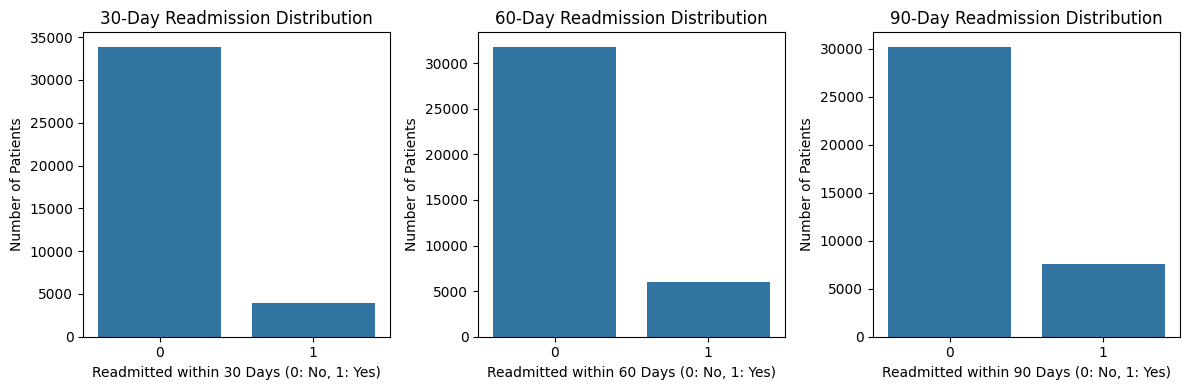


Readmission Rates by Age Group:


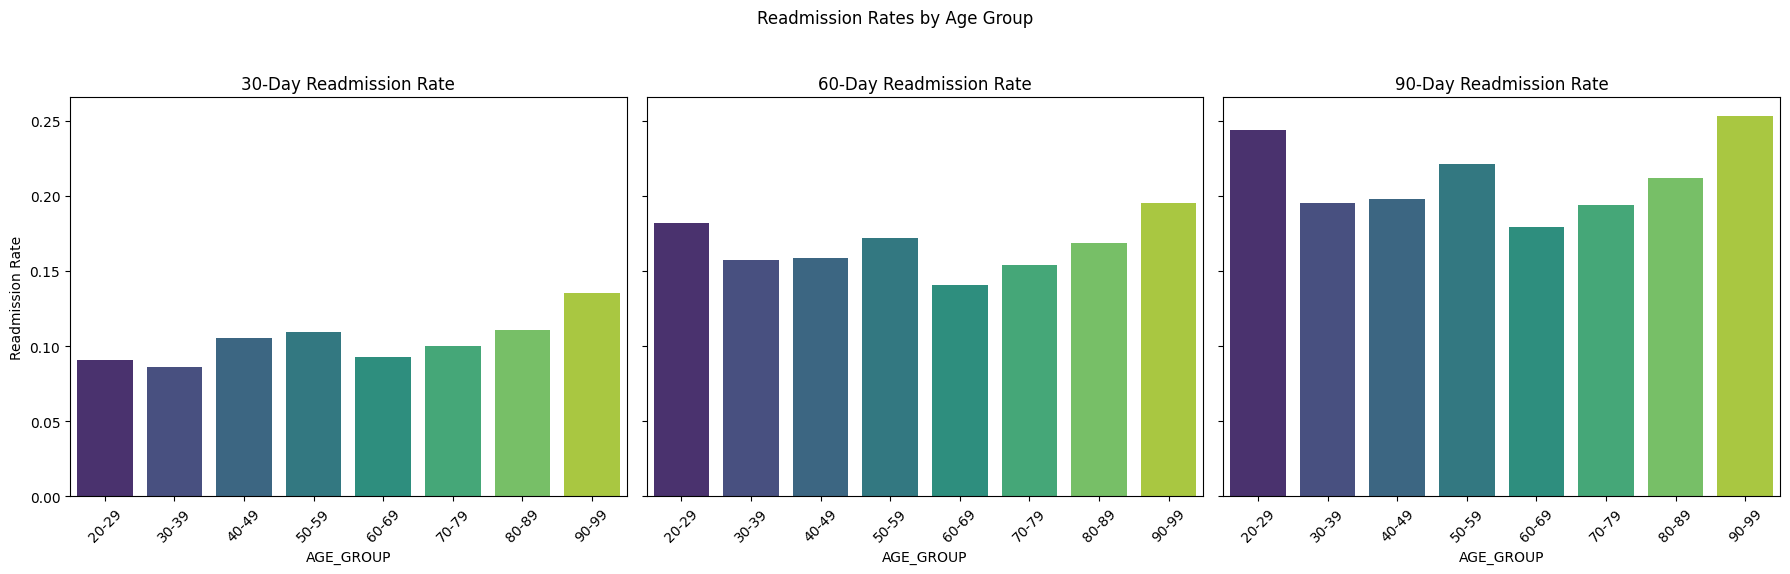


Readmission rates by chronic condition:


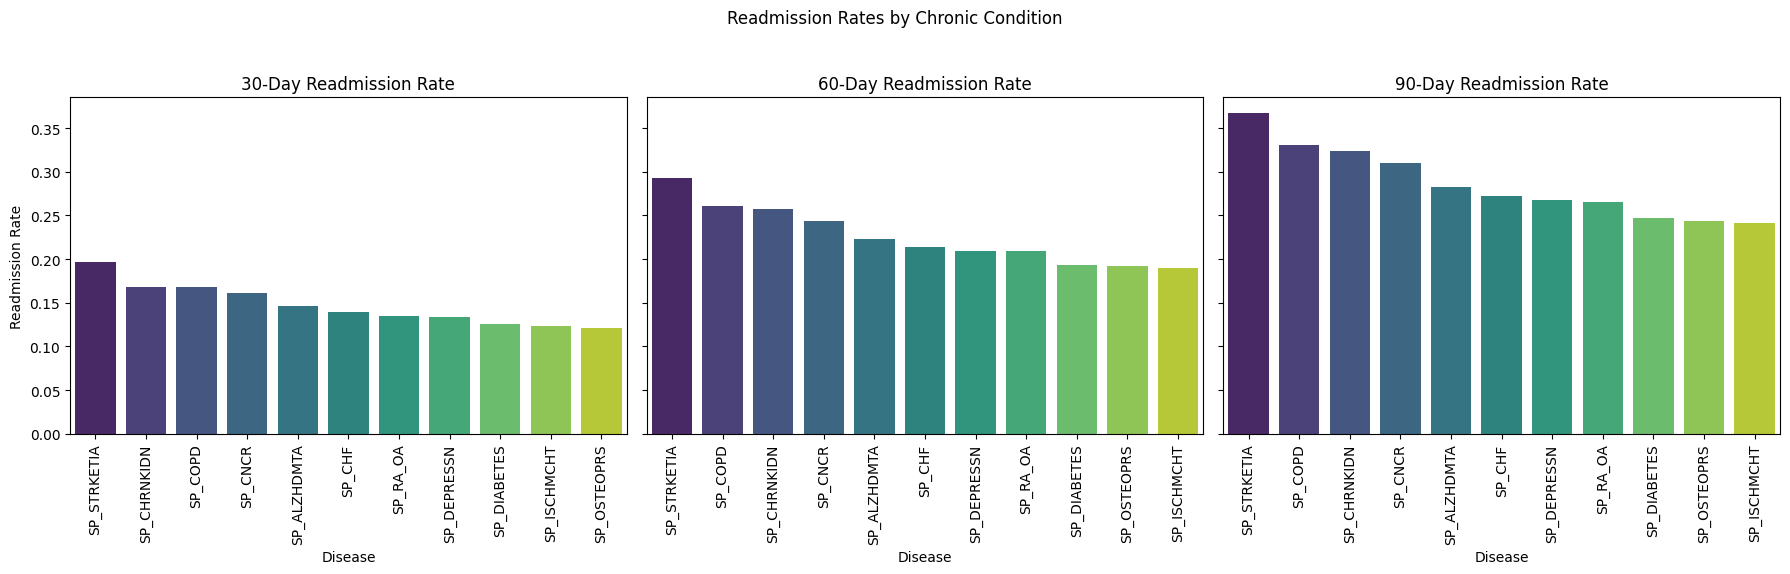

In [ ]:
# Exploratory Data Analysis (EDA) focused on Readmission Outcomes

# 1. Distribution of Readmission Flags
print("Distribution of Readmission Flags:")
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x='READMIT_30', data=df)
plt.title('30-Day Readmission Distribution')
plt.xlabel('Readmitted within 30 Days (0: No, 1: Yes)')
plt.ylabel('Number of Patients')

plt.subplot(1, 3, 2)
sns.countplot(x='READMIT_60', data=df)
plt.title('60-Day Readmission Distribution')
plt.xlabel('Readmitted within 60 Days (0: No, 1: Yes)')
plt.ylabel('Number of Patients')

plt.subplot(1, 3, 3)
sns.countplot(x='READMIT_90', data=df)
plt.title('90-Day Readmission Distribution')
plt.xlabel('Readmitted within 90 Days (0: No, 1: Yes)')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

# 2. Readmission Rate by Age Group
# Create age groups (e.g., in bins of 10 or 20 years)
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=np.arange(20, 101, 10), right=False, labels=[f'{i}-{i+9}' for i in range(20, 91, 10)])

readmission_by_age_30 = df.groupby('AGE_GROUP')['READMIT_30'].mean().reset_index()
readmission_by_age_60 = df.groupby('AGE_GROUP')['READMIT_60'].mean().reset_index()
readmission_by_age_90 = df.groupby('AGE_GROUP')['READMIT_90'].mean().reset_index()

print("\nReadmission Rates by Age Group:")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Readmission Rates by Age Group')

sns.barplot(ax=axes[0], x='AGE_GROUP', y='READMIT_30', data=readmission_by_age_30, palette='viridis')
axes[0].set_title('30-Day Readmission Rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Readmission Rate')

sns.barplot(ax=axes[1], x='AGE_GROUP', y='READMIT_60', data=readmission_by_age_60, palette='viridis')
axes[1].set_title('60-Day Readmission Rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('')

sns.barplot(ax=axes[2], x='AGE_GROUP', y='READMIT_90', data=readmission_by_age_90, palette='viridis')
axes[2].set_title('90-Day Readmission Rate')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# 3. Readmission Rate by Chronic Condition (Revisiting with visualization)
# Already calculated in a previous step, just adding visualization here for completeness of EDA section
chronic_cols = ['SP_ALZHDMTA','SP_CHF','SP_CHRNKIDN','SP_CNCR','SP_COPD','SP_DEPRESSN',
                'SP_DIABETES','SP_ISCHMCHT','SP_OSTEOPRS','SP_RA_OA','SP_STRKETIA']

# Calculate readmission rates for each chronic condition (re-calculate for consistency)
df_melted = df.melt(id_vars=['DESYNPUF_ID', 'READMIT_30', 'READMIT_60', 'READMIT_90'],
                    value_vars=chronic_cols,
                    var_name='Disease',
                    value_name='Has_Disease')

df_diseased = df_melted[df_melted['Has_Disease'] == 1]

readmission_by_disease_30 = df_diseased.groupby('Disease')['READMIT_30'].mean().reset_index()
readmission_by_disease_60 = df_diseased.groupby('Disease')['READMIT_60'].mean().reset_index()
readmission_by_disease_90 = df_diseased.groupby('Disease')['READMIT_90'].mean().reset_index()

readmission_by_disease = readmission_by_disease_30.merge(readmission_by_disease_60, on='Disease')
readmission_by_disease = readmission_by_disease.merge(readmission_by_disease_90, on='Disease')
readmission_by_disease.columns = ['Disease', 'Readmit_30_Rate', 'Readmit_60_Rate', 'Readmit_90_Rate']

print("\nReadmission rates by chronic condition:")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Readmission Rates by Chronic Condition')

sns.barplot(ax=axes[0], x='Disease', y='Readmit_30_Rate', data=readmission_by_disease.sort_values('Readmit_30_Rate', ascending=False), palette='viridis')
axes[0].set_title('30-Day Readmission Rate')
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_ylabel('Readmission Rate')

sns.barplot(ax=axes[1], x='Disease', y='Readmit_60_Rate', data=readmission_by_disease.sort_values('Readmit_60_Rate', ascending=False), palette='viridis')
axes[1].set_title('60-Day Readmission Rate')
axes[1].tick_params(axis='x', rotation=90)
axes[1].set_ylabel('')

sns.barplot(ax=axes[2], x='Disease', y='Readmit_90_Rate', data=readmission_by_disease.sort_values('Readmit_90_Rate', ascending=False), palette='viridis')
axes[2].set_title('90-Day Readmission Rate')
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



#


# You can add more visualizations exploring relationships between other features (e.g., total reimbursement, coverage months) and readmission rates.

In [ ]:
# Feature Engineering Examples:

# 1. Total Reimbursement and Payment Features:
df['TOTAL_REIMB'] = df['MEDREIMB_IP'] + df['MEDREIMB_OP'] + df['MEDREIMB_CAR']
df['TOTAL_BENRES'] = df['BENRES_IP'] + df['BENRES_OP'] + df['BENRES_CAR']
df['TOTAL_PPPYMT'] = df['PPPYMT_IP'] + df['PPPYMT_OP'] + df['PPPYMT_CAR']

# 2. Ratio Features (e.g., proportion of different payment types):
# Add a small epsilon to avoid division by zero if total is 0
epsilon = 1e-6
df['IP_REIMB_RATIO'] = df['MEDREIMB_IP'] / (df['TOTAL_REIMB'] + epsilon)
df['OP_REIMB_RATIO'] = df['MEDREIMB_OP'] / (df['TOTAL_REIMB'] + epsilon)
df['CAR_REIMB_RATIO'] = df['MEDREIMB_CAR'] / (df['TOTAL_REIMB'] + epsilon)

# 3. Interaction Terms (Example: Age and presence of a chronic condition)
# df['AGE_x_DIABETES'] = df['AGE'] * df['SP_DIABETES']
# df['AGE_x_CHF'] = df['AGE'] * df['SP_CHF']


# 4. Polynomial Features (Example: Age squared)
# df['AGE_SQUARED'] = df['AGE']**2

# Display the new features and the updated dataframe head
print("New engineered features created.")
display(df[['TOTAL_REIMB', 'TOTAL_BENRES', 'TOTAL_PPPYMT',
            'IP_REIMB_RATIO', 'OP_REIMB_RATIO', 'CAR_REIMB_RATIO']].head())

print("\nUpdated DataFrame head with engineered features:")
display(df.head())

New engineered features created.


,TOTAL_REIMB,TOTAL_BENRES,TOTAL_PPPYMT,IP_REIMB_RATIO,OP_REIMB_RATIO,CAR_REIMB_RATIO
0,50,10,0,0.000000,1.000000,0.000000
1,700,240,0,0.000000,0.000000,1.000000
2,24980,6284,1200,0.560448,0.169736,0.269816
3,15490,3574,200,0.322789,0.355713,0.321498
4,1020,290,0,0.000000,0.000000,1.000000



Updated DataFrame head with engineered features:


,DESYNPUF_ID,CLM_ID_x,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_ID_y,CLM_FROM_DT,CLM_THRU_DT,BENE_BIRTH_DT,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE,READMIT_30,READMIT_60,READMIT_90,AGE_GROUP,TOTAL_REIMB,TOTAL_BENRES,TOTAL_PPPYMT,IP_REIMB_RATIO,OP_REIMB_RATIO,CAR_REIMB_RATIO
0,00013D2EFD8E45D1,196661000000000.0,2010-03-12,2010-03-13,542192000000000.0,2008-09-04,2008-09-04,1923-01-05,1,26,950,12,12,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,10,0,0,0,0,2008,85,0,0,0,80-89,50,10,0,0.000000,1.000000,0.000000
1,00016F745862898F,196201000000000.0,2009-04-12,2009-04-18,542272000000000.0,2009-06-02,2009-06-02,1943-01-01,1,39,230,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,700,240,0,2008,65,0,0,0,60-69,700,240,0,0.000000,0.000000,1.000000
2,00052705243EA128,196991000000000.0,2008-09-12,2008-09-12,542672000000000.0,NaT,NaT,1934-01-05,1,14,982,12,12,0,5,0,1,0,1,0,1,1,1,0,0,0,14000,1024,0,4240,3130,0,6740,2130,1200,2008,74,0,0,0,70-79,24980,6284,1200,0.560448,0.169736,0.269816
3,0007F12A492FD25D,196661000000000.0,2008-09-19,2008-09-22,542202000000000.0,2008-03-05,2008-03-05,1919-01-09,2,34,400,12,12,12,12,1,1,0,0,1,1,1,1,1,1,1,5000,1024,0,5510,1380,0,4980,1170,200,2008,89,0,0,0,80-89,15490,3574,200,0.322789,0.355713,0.321498
4,000B97BA2314E971,196231000000000.0,2009-12-09,2009-12-13,NO_OUTPATIENT_CLAIM,NaT,NaT,1938-01-04,1,22,20,12,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1020,290,0,2008,70,0,0,0,70-79,1020,290,0,0.000000,0.000000,1.000000



Outliers corrected using capping at 95th percentile.


,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE,READMIT_30,READMIT_60,READMIT_90,TOTAL_REIMB,TOTAL_BENRES,TOTAL_PPPYMT,IP_REIMB_RATIO,OP_REIMB_RATIO,CAR_REIMB_RATIO
count,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.0,37780.000000,37780.000000,37780.0,37780.000000,37780.000000,37780.000000,37780.0,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000,37780.000000
mean,1.205003,25.556432,374.169508,11.526840,11.389704,2.563737,7.177422,0.361832,0.534966,0.356432,0.126257,0.304129,0.377978,0.641874,0.702832,0.278084,0.277290,0.109026,5790.615405,680.563049,0.0,932.914240,305.946533,0.0,2041.117787,571.921387,19.858391,2008.0,72.413155,0.103653,0.158497,0.200794,9106.326840,1612.406535,41.308100,0.298371,0.175896,0.490902
std,0.518108,14.954339,260.723779,2.177734,2.433930,4.833596,5.781909,0.480537,0.498783,0.478951,0.332143,0.460044,0.484888,0.479456,0.457017,0.448061,0.447667,0.311676,9624.016116,951.636000,0.0,1250.425851,421.156140,0.0,1602.517931,444.457419,45.646531,0.0,12.580359,0.304814,0.365211,0.400600,11223.277564,1456.349738,100.443543,0.377945,0.214989,0.359951
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.000000,0.0,-90.000000,0.000000,0.0,0.000000,0.000000,0.000000,2008.0,25.000000,0.000000,0.000000,0.000000,-430.000000,0.000000,0.000000,-2.222222,-0.800000,-10.111111
25%,1.000000,11.000000,141.000000,12.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,30.000000,0.000000,0.0,760.000000,210.000000,0.000000,2008.0,67.000000,0.000000,0.000000,0.000000,1430.000000,430.000000,0.000000,0.000000,0.003266,0.153738
50%,1.000000,25.000000,342.000000,12.000000,12.000000,0.000000,12.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,390.000000,110.000000,0.0,1620.000000,460.000000,0.000000,2008.0,74.000000,0.000000,0.000000,0.000000,4120.000000,1210.000000,0.000000,0.000000,0.077223,0.427195
75%,1.000000,38.000000,570.000000,12.000000,12.000000,0.000000,12.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,8000.000000,1024.000000,0.0,1300.000000,430.000000,0.0,3040.000000,850.000000,0.000000,2008.0,81.000000,0.000000,0.000000,0.000000,12360.000000,2384.000000,20.000000,0.717033,0.283668,0.862473
max,3.000000,50.000000,880.000000,12.000000,12.000000,12.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,34000.000000,3072.000000,0.0,4430.000000,1480.000000,0.0,5670.000000,1570.000000,180.000000,2008.0,91.000000,1.000000,1.000000,1.000000,40972.000000,5210.100000,400.000000,0.929752,0.697444,1.000000


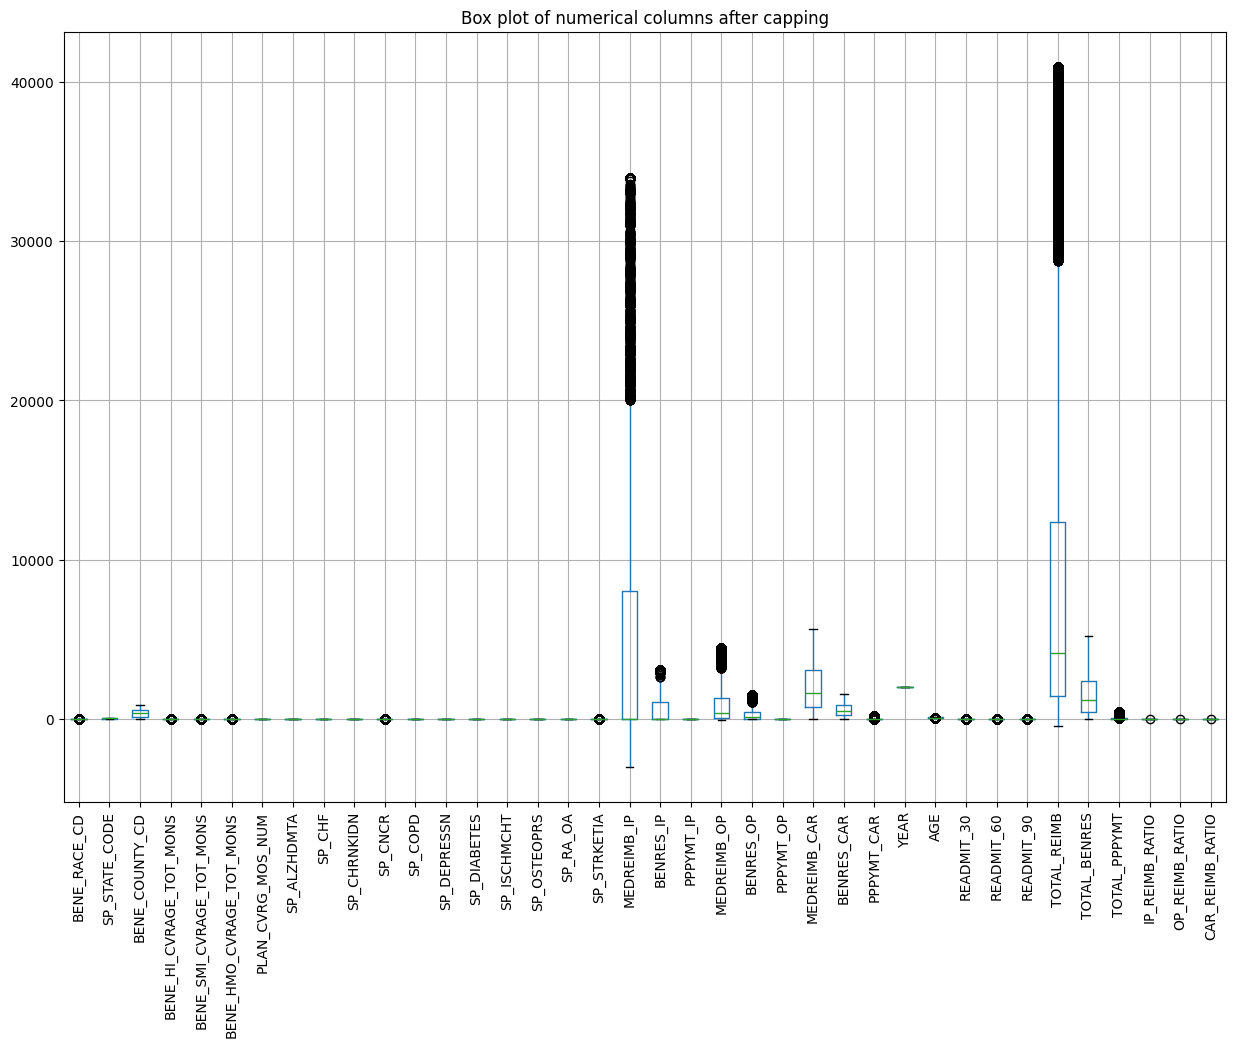

In [ ]:
# Correct outliers using capping (e.g., at the 95th percentile)
# This is a common approach for handling outliers in financial data.
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
for col in numerical_cols:
    upper_limit = df[col].quantile(0.95)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("\nOutliers corrected using capping at 95th percentile.")
display(df[numerical_cols].describe())

# You can visualize again to see the effect of capping
plt.figure(figsize=(15, 10))
df[numerical_cols].boxplot()
plt.title('Box plot of numerical columns after capping')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.to_csv("/content/drive/MyDrive/Dataset/dfmerge",index=False)

In [ ]:
# ========================================
# 📌 STEP 1: Feature Selection
# ========================================

# Define the features (X) and target variables (y)
# We will exclude ID columns, date columns, and the target variables themselves from the features.
# We will also exclude the engineered AGE_GROUP for now, as AGE is included.

feature_cols = [col for col in df.columns if col not in ['DESYNPUF_ID', 'CLM_ID_x', 'CLM_ID_y',
                                                         'CLM_ADMSN_DT', 'NCH_BENE_DSCHRG_DT',
                                                         'CLM_FROM_DT', 'CLM_THRU_DT',
                                                         'BENE_BIRTH_DT', 'AGE_GROUP',
                                                         'READMIT_30', 'READMIT_60', 'READMIT_90']]

X = df[feature_cols]
y = df[['READMIT_30', 'READMIT_60', 'READMIT_90']]

print("Features (X) shape:", X.shape)
print("Target variables (y) shape:", y.shape)
display(X.head())
display(y.head())

# Identify categorical and numerical columns for preprocessing
categorical_cols = X.select_dtypes(include='object').columns.tolist()
# Exclude the 'CLM_ID_y' placeholder if it's in categorical_cols and you don't want to one-hot encode it
if 'CLM_ID_y' in categorical_cols:
    categorical_cols.remove('CLM_ID_y') # Assuming we don't want to OHE the placeholder

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Note: The cost estimation for cancer will be addressed later in the plan, likely after model prediction.

Features (X) shape: (37780, 35)
Target variables (y) shape: (37780, 3)


,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE,TOTAL_REIMB,TOTAL_BENRES,TOTAL_PPPYMT,IP_REIMB_RATIO,OP_REIMB_RATIO,CAR_REIMB_RATIO
0,1.0,26.0,880.0,12.0,12.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,10.0,0.0,0.0,0.0,0.0,2008.0,85.0,50.0,10.0,0.0,0.000000,0.697444,0.000000
1,1.0,39.0,230.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700.0,240.0,0.0,2008.0,65.0,700.0,240.0,0.0,0.000000,0.000000,1.000000
2,1.0,14.0,880.0,12.0,12.0,0.0,5.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,14000.0,1024.0,0.0,4240.0,1480.0,0.0,5670.0,1570.0,180.0,2008.0,74.0,24980.0,5210.1,400.0,0.560448,0.169736,0.269816
3,2.0,34.0,400.0,12.0,12.0,12.0,12.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5000.0,1024.0,0.0,4430.0,1380.0,0.0,4980.0,1170.0,180.0,2008.0,89.0,15490.0,3574.0,200.0,0.322789,0.355713,0.321498
4,1.0,22.0,20.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1020.0,290.0,0.0,2008.0,70.0,1020.0,290.0,0.0,0.000000,0.000000,1.000000


,READMIT_30,READMIT_60,READMIT_90
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0



Categorical columns: []
Numerical columns: ['BENE_RACE_CD', 'SP_STATE_CODE', 'BENE_COUNTY_CD', 'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS', 'BENE_HMO_CVRAGE_TOT_MONS', 'PLAN_CVRG_MOS_NUM', 'SP_ALZHDMTA', 'SP_CHF', 'SP_CHRNKIDN', 'SP_CNCR', 'SP_COPD', 'SP_DEPRESSN', 'SP_DIABETES', 'SP_ISCHMCHT', 'SP_OSTEOPRS', 'SP_RA_OA', 'SP_STRKETIA', 'MEDREIMB_IP', 'BENRES_IP', 'PPPYMT_IP', 'MEDREIMB_OP', 'BENRES_OP', 'PPPYMT_OP', 'MEDREIMB_CAR', 'BENRES_CAR', 'PPPYMT_CAR', 'YEAR', 'AGE', 'TOTAL_REIMB', 'TOTAL_BENRES', 'TOTAL_PPPYMT', 'IP_REIMB_RATIO', 'OP_REIMB_RATIO', 'CAR_REIMB_RATIO']


In [ ]:
# ========================================
# 📌 STEP 2: Data Splitting
# ========================================

# Split data into training and testing sets
# Using GroupShuffleSplit to ensure that all records for a single patient are either in the train or test set
# This prevents data leakage
group_col = df['DESYNPUF_ID']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Get the train and test indices
train_idx, test_idx = next(gss.split(X, y, groups=group_col))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (30224, 35)
X_test shape: (7556, 35)
y_train shape: (30224, 3)
y_test shape: (7556, 3)


In [ ]:
# ========================================
# 📌 STEP 3: Preprocessing
# ========================================

# Create preprocessing pipelines for numerical and categorical features
# Numerical features: Impute missing values with mean and then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical features: One-hot encode (if any)
# Since there are no categorical columns identified in X (excluding CLM_ID_y),
# this transformer might not be strictly necessary for this dataset based on the current feature selection.
# However, it's good practice to include if categorical features were present or added later.
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


# Create a column transformer to apply different preprocessing steps to different columns
# Check if categorical_cols is empty before including it in the ColumnTransformer
if categorical_cols:
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ],
        remainder='passthrough' # Keep other columns (like IDs if they were included in X)
    )
else:
    # If no categorical columns, only apply numerical transformation
     preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols)
        ],
        remainder='passthrough'
    )


# Apply the preprocessing to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape of processed training data:", X_train_processed.shape)
print("Shape of processed testing data:", X_test_processed.shape)

Shape of processed training data: (30224, 35)
Shape of processed testing data: (7556, 35)


In [ ]:
# ========================================
# 📌 STEP 4: Model Training
# ========================================

# Train separate classification models for each readmission window (30, 60, and 90 days).
# Given the class imbalance observed in the EDA, consider techniques like SMOTE.

# Define the target variables for each readmission window
y_train_30 = y_train['READMIT_30']
y_train_60 = y_train['READMIT_60']
y_train_90 = y_train['READMIT_90']

# Initialize models (Using RandomForestClassifier and XGBClassifier as examples)
# You can experiment with different models and hyperparameters
model_rf_30 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_xgb_30 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

model_rf_60 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_xgb_60 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

model_rf_90 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_xgb_90 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')


# Train the models
print("Training models...")

print("Training 30-day readmission models...")
model_rf_30.fit(X_train_processed, y_train_30)
model_xgb_30.fit(X_train_processed, y_train_30)

print("Training 60-day readmission models...")
model_rf_60.fit(X_train_processed, y_train_60)
model_xgb_60.fit(X_train_processed, y_train_60)

print("Training 90-day readmission models...")
model_rf_90.fit(X_train_processed, y_train_90)
model_xgb_90.fit(X_train_processed, y_train_90)

print("Model training complete.")

Training models...
Training 30-day readmission models...
Training 60-day readmission models...
Training 90-day readmission models...
Model training complete.


In [ ]:
# ========================================
# 📌 STEP 5: Prediction
# ========================================

# Make predictions on the test set for each model
print("Making predictions on the test set...")

# Random Forest Predictions
y_pred_rf_30 = model_rf_30.predict(X_test_processed)
y_pred_proba_rf_30 = model_rf_30.predict_proba(X_test_processed)[:, 1]

y_pred_rf_60 = model_rf_60.predict(X_test_processed)
y_pred_proba_rf_60 = model_rf_60.predict_proba(X_test_processed)[:, 1]

y_pred_rf_90 = model_rf_90.predict(X_test_processed)
y_pred_proba_rf_90 = model_rf_90.predict_proba(X_test_processed)[:, 1]

# XGBoost Predictions
y_pred_xgb_30 = model_xgb_30.predict(X_test_processed)
y_pred_proba_xgb_30 = model_xgb_30.predict_proba(X_test_processed)[:, 1]

y_pred_xgb_60 = model_xgb_60.predict(X_test_processed)
y_pred_proba_xgb_60 = model_xgb_60.predict_proba(X_test_processed)[:, 1]

y_pred_xgb_90 = model_xgb_90.predict(X_test_processed)
y_pred_proba_xgb_90 = model_xgb_90.predict_proba(X_test_processed)[:, 1]

print("Predictions complete.")

Making predictions on the test set...
Predictions complete.


In [ ]:
# ========================================
# 📌 STEP 6: Evaluation
# ========================================

# Evaluate the performance of the classification models using appropriate metrics.
# We will use Classification Report (precision, recall, f1-score) and AUC.

print("Evaluating model performance...")

# Random Forest Evaluation
print("\n--- Random Forest Model Evaluation ---")

print("\n30-Day Readmission (Random Forest):")
# Classification Report: Provides precision, recall, f1-score, and support for each class.
# Precision: The ability of the classifier not to label as positive a sample that is negative.
# Recall: The ability of the classifier to find all the positive samples.
# F1-score: A weighted harmonic mean of precision and recall.
# Support: The number of occurrences of each class in y_test.
print(classification_report(y_test['READMIT_30'], y_pred_rf_30))
# ROC AUC: Area Under the Receiver Operating Characteristic Curve.
# It measures the model's ability to distinguish between the positive and negative classes.
# A higher AUC indicates better performance.
roc_auc_30 = roc_auc_score(y_test['READMIT_30'], y_pred_proba_rf_30)
print(f"AUC: {roc_auc_30:.4f}")
print("Confusion Matrix:")
# Confusion Matrix: A table used to evaluate the performance of a classification model.
# It shows the counts of true positives, true negatives, false positives, and false negatives.
display(confusion_matrix(y_test['READMIT_30'], y_pred_rf_30))


print("\n60-Day Readmission (Random Forest):")
print(classification_report(y_test['READMIT_60'], y_pred_rf_60))
roc_auc_60 = roc_auc_score(y_test['READMIT_60'], y_pred_proba_rf_60)
print(f"AUC: {roc_auc_60:.4f}")
print("Confusion Matrix:")
display(confusion_matrix(y_test['READMIT_60'], y_pred_rf_60))

print("\n90-Day Readmission (Random Forest):")
print(classification_report(y_test['READMIT_90'], y_pred_rf_90))
roc_auc_90 = roc_auc_score(y_test['READMIT_90'], y_pred_proba_rf_90)
print(f"AUC: {roc_auc_90:.4f}")
print("Confusion Matrix:")
display(confusion_matrix(y_test['READMIT_90'], y_pred_rf_90))


# XGBoost Evaluation
print("\n--- XGBoost Model Evaluation ---")

print("\n30-Day Readmission (XGBoost):")
print(classification_report(y_test['READMIT_30'], y_pred_xgb_30))
roc_auc_30_xgb = roc_auc_score(y_test['READMIT_30'], y_pred_proba_xgb_30)
print(f"AUC: {roc_auc_30_xgb:.4f}")
print("Confusion Matrix:")
display(confusion_matrix(y_test['READMIT_30'], y_pred_xgb_30))

print("\n60-Day Readmission (XGBoost):")
print(classification_report(y_test['READMIT_60'], y_pred_xgb_60))
roc_auc_60_xgb = roc_auc_score(y_test['READMIT_60'], y_pred_proba_xgb_60)
print(f"AUC: {roc_auc_60_xgb:.4f}")
print("Confusion Matrix:")
display(confusion_matrix(y_test['READMIT_60'], y_pred_xgb_60))

print("\n90-Day Readmission (XGBoost):")
print(classification_report(y_test['READMIT_90'], y_pred_xgb_90))
roc_auc_90_xgb = roc_auc_score(y_test['READMIT_90'], y_pred_proba_xgb_90)
print(f"AUC: {roc_auc_90_xgb:.4f}")
print("Confusion Matrix:")
display(confusion_matrix(y_test['READMIT_90'], y_pred_xgb_90))


print("\nModel evaluation complete.")

Evaluating model performance...

--- Random Forest Model Evaluation ---

30-Day Readmission (Random Forest):
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95      6806
         1.0       0.48      0.02      0.03       750

    accuracy                           0.90      7556
   macro avg       0.69      0.51      0.49      7556
weighted avg       0.86      0.90      0.86      7556

AUC: 0.7712
Confusion Matrix:


array([[6793,   13],
       [ 738,   12]])


60-Day Readmission (Random Forest):
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92      6419
         1.0       0.57      0.24      0.34      1137

    accuracy                           0.86      7556
   macro avg       0.72      0.60      0.63      7556
weighted avg       0.83      0.86      0.83      7556

AUC: 0.8016
Confusion Matrix:


array([[6213,  206],
       [ 862,  275]])


90-Day Readmission (Random Forest):
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91      6123
         1.0       0.66      0.50      0.57      1433

    accuracy                           0.86      7556
   macro avg       0.78      0.72      0.74      7556
weighted avg       0.85      0.86      0.85      7556

AUC: 0.8211
Confusion Matrix:


...


60-Day Readmission (XGBoost):
              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92      6419
         1.0       0.53      0.31      0.39      1137

    accuracy                           0.85      7556
   macro avg       0.71      0.63      0.65      7556
weighted avg       0.83      0.85      0.84      7556

AUC: 0.7846
Confusion Matrix:


array([[6100,  319],
       [ 782,  355]])


90-Day Readmission (XGBoost):
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91      6123
         1.0       0.66      0.50      0.57      1433

    accuracy                           0.86      7556
   macro avg       0.77      0.72      0.74      7556
weighted avg       0.84      0.86      0.85      7556

AUC: 0.8104
Confusion Matrix:


array([[5750,  373],
       [ 719,  714]])


Model evaluation complete.


In [ ]:
# ========================================
# 📌 STEP 7: Cost Estimation
# ========================================

# Estimate the cost associated with readmissions, focusing on cancer patients.
# This requires defining what constitutes the "cost" of a readmission and
# identifying cancer patients.

# For simplicity, let's assume the cost of a readmission is the total reimbursement
# amount (TOTAL_REIMB) for that patient in the given year.
# A more accurate cost estimation would require more granular data and a defined cost model.

# Identify patients with cancer (SP_CNCR == 1) in the test set
cancer_patients_test_idx = X_test[X_test['SP_CNCR'] == 1].index

# Filter the original dataframe to get the cost information for these cancer patients in the test set
cancer_patients_df_test = df.loc[cancer_patients_test_idx]

# Now, let's estimate the cost of predicted readmissions for these cancer patients.
# We will use the predictions from one of the models (e.g., XGBoost for 30-day readmission)
# You can choose a different model or readmission window as needed.

# Get the predicted readmission status for cancer patients in the test set (using XGBoost 30-day model)
# Ensure the order of predictions matches the filtered test set
y_pred_xgb_30_cancer = model_xgb_30.predict(X_test_processed[X_test.index.isin(cancer_patients_test_idx)])

# Add the predicted readmission flag to the cancer patients dataframe
cancer_patients_df_test['PREDICTED_READMIT_30_XGB'] = y_pred_xgb_30_cancer

# Calculate the estimated total cost of predicted readmissions for cancer patients
estimated_cost_cancer_30 = cancer_patients_df_test[cancer_patients_df_test['PREDICTED_READMIT_30_XGB'] == 1]['TOTAL_REIMB'].sum()

print(f"\nEstimated total cost of predicted 30-day readmissions for cancer patients (using XGBoost): ${estimated_cost_cancer_30:,.2f}")

# You can repeat this for 60-day and 90-day readmissions and for different models.

# Additionally, you can estimate the average cost per predicted readmission for cancer patients
num_predicted_readmissions_cancer_30 = cancer_patients_df_test['PREDICTED_READMIT_30_XGB'].sum()

if num_predicted_readmissions_cancer_30 > 0:
    average_cost_per_readmission_cancer_30 = estimated_cost_cancer_30 / num_predicted_readmissions_cancer_30
    print(f"Estimated average cost per predicted 30-day readmission for cancer patients: ${average_cost_per_readmission_cancer_30:,.2f}")
else:
    print("No 30-day readmissions predicted for cancer patients in the test set.")


# To estimate the cost for all patients (not just cancer), you can use the full test set predictions:
estimated_cost_30 = df.loc[X_test.index][y_pred_xgb_30 == 1]['TOTAL_REIMB'].sum()
estimated_cost_60 = df.loc[X_test.index][y_pred_xgb_60 == 1]['TOTAL_REIMB'].sum()
estimated_cost_90 = df.loc[X_test.index][y_pred_xgb_90 == 1]['TOTAL_REIMB'].sum()


print(f"\nEstimated total cost of predicted 30-day readmissions (all patients, using XGBoost): ${estimated_cost_30:,.2f}")
print(f"Estimated total cost of predicted 60-day readmissions (all patients, using XGBoost): ${estimated_cost_60:,.2f}")
print(f"Estimated total cost of predicted 90-day readmissions (all patients, using XGBoost): ${estimated_cost_90:,.2f}")

# Average cost per readmission (all patients)
num_predicted_readmissions_30 = (y_pred_xgb_30 == 1).sum()
num_predicted_readmissions_60 = (y_pred_xgb_60 == 1).sum()
num_predicted_readmissions_90 = (y_pred_xgb_90 == 1).sum()

avg_readmission_cost_30 = estimated_cost_30 / num_predicted_readmissions_30 if num_predicted_readmissions_30 > 0 else 0
avg_readmission_cost_60 = estimated_cost_60 / num_predicted_readmissions_60 if num_predicted_readmissions_60 > 0 else 0
avg_readmission_cost_90 = estimated_cost_90 / num_predicted_readmissions_90 if num_predicted_readmissions_90 > 0 else 0

print(f"\nEstimated average cost per predicted 30-day readmission (all patients, using XGBoost): ${avg_readmission_cost_30:,.2f}")
print(f"Estimated average cost per predicted 60-day readmission (all patients, using XGBoost): ${avg_readmission_cost_60:,.2f}")
print(f"Estimated average cost per predicted 90-day readmission (all patients, using XGBoost): ${avg_readmission_cost_90:,.2f}")

# Note: This cost estimation is a simplified example. A real-world scenario would require
# a more robust cost model, potentially using claim-level cost data and considering
# different types of costs (e.g., direct medical costs, indirect costs).


Estimated total cost of predicted 30-day readmissions for cancer patients (using XGBoost): $1,274,768.00
Estimated average cost per predicted 30-day readmission for cancer patients: $33,546.53

Estimated total cost of predicted 30-day readmissions (all patients, using XGBoost): $4,450,274.00
Estimated total cost of predicted 60-day readmissions (all patients, using XGBoost): $18,647,222.00
Estimated total cost of predicted 90-day readmissions (all patients, using XGBoost): $28,996,376.00

Estimated average cost per predicted 30-day readmission (all patients, using XGBoost): $28,166.29
Estimated average cost per predicted 60-day readmission (all patients, using XGBoost): $27,666.50
Estimated average cost per predicted 90-day readmission (all patients, using XGBoost): $26,675.60


In [ ]:
df.head()

,DESYNPUF_ID,CLM_ID_x,CLM_ADMSN_DT,NCH_BENE_DSCHRG_DT,CLM_ID_y,CLM_FROM_DT,CLM_THRU_DT,BENE_BIRTH_DT,BENE_RACE_CD,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,YEAR,AGE,READMIT_30,READMIT_60,READMIT_90,AGE_GROUP,TOTAL_REIMB,TOTAL_BENRES,TOTAL_PPPYMT,IP_REIMB_RATIO,OP_REIMB_RATIO,CAR_REIMB_RATIO
0,00013D2EFD8E45D1,196661000000000.0,2010-03-12,2010-03-13,542192000000000.0,2008-09-04,2008-09-04,1923-01-05,1.0,26.0,880.0,12.0,12.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,10.0,0.0,0.0,0.0,0.0,2008.0,85.0,0.0,0.0,0.0,80-89,50.0,10.0,0.0,0.000000,0.697444,0.000000
1,00016F745862898F,196201000000000.0,2009-04-12,2009-04-18,542272000000000.0,2009-06-02,2009-06-02,1943-01-01,1.0,39.0,230.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,700.0,240.0,0.0,2008.0,65.0,0.0,0.0,0.0,60-69,700.0,240.0,0.0,0.000000,0.000000,1.000000
2,00052705243EA128,196991000000000.0,2008-09-12,2008-09-12,542672000000000.0,NaT,NaT,1934-01-05,1.0,14.0,880.0,12.0,12.0,0.0,5.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,14000.0,1024.0,0.0,4240.0,1480.0,0.0,5670.0,1570.0,180.0,2008.0,74.0,0.0,0.0,0.0,70-79,24980.0,5210.1,400.0,0.560448,0.169736,0.269816
3,0007F12A492FD25D,196661000000000.0,2008-09-19,2008-09-22,542202000000000.0,2008-03-05,2008-03-05,1919-01-09,2.0,34.0,400.0,12.0,12.0,12.0,12.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5000.0,1024.0,0.0,4430.0,1380.0,0.0,4980.0,1170.0,180.0,2008.0,89.0,0.0,0.0,0.0,80-89,15490.0,3574.0,200.0,0.322789,0.355713,0.321498
4,000B97BA2314E971,196231000000000.0,2009-12-09,2009-12-13,NO_OUTPATIENT_CLAIM,NaT,NaT,1938-01-04,1.0,22.0,20.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1020.0,290.0,0.0,2008.0,70.0,0.0,0.0,0.0,70-79,1020.0,290.0,0.0,0.000000,0.000000,1.000000


In [ ]:
# ========================================
# 📌 Individual Patient Prediction
# ========================================

def predict_readmission_by_id(patient_id, dataframe, preprocessor, rf_models, xgb_models, feature_cols):
    """
    Predicts readmission probability for a specific patient ID.

    Args:
        patient_id (str): The DESYNPUF_ID of the patient.
        dataframe (pd.DataFrame): The preprocessed dataframe containing patient data.
        preprocessor: The fitted ColumnTransformer for preprocessing.
        rf_models (dict): A dictionary of trained RandomForestClassifier models
                          {'30': model_rf_30, '60': model_rf_60, '90': model_rf_90}.
        xgb_models (dict): A dictionary of trained XGBClassifier models
                           {'30': model_xgb_30, '60': model_xgb_60, '90': model_xgb_90}.
        feature_cols (list): A list of feature column names used for training.

    Returns:
        dict: A dictionary containing predicted readmission probabilities for the patient,
              or None if the patient ID is not found.
    """
    # Retrieve the patient's data
    patient_data = dataframe[dataframe['DESYNPUF_ID'] == patient_id]

    if patient_data.empty:
        print(f"Patient with ID '{patient_id}' not found in the dataframe.")
        return None

    # Select the features for the patient
    patient_features = patient_data[feature_cols]

    # Preprocess the patient's features
    patient_features_processed = preprocessor.transform(patient_features)

    # Make predictions using each model
    predictions = {}
    for window in ['30', '60', '90']:
        # Random Forest
        rf_model = rf_models[window]
        rf_proba = rf_model.predict_proba(patient_features_processed)[:, 1][0]
        predictions[f'RF_{window}D_Readmit_Proba'] = rf_proba

        # XGBoost
        xgb_model = xgb_models[window]
        xgb_proba = xgb_model.predict_proba(patient_features_processed)[:, 1][0]
        predictions[f'XGB_{window}D_Readmit_Proba'] = xgb_proba

    return predictions

# Example usage:
# Assuming 'df', 'preprocessor', 'model_rf_30', 'model_rf_60', 'model_rf_90',
# 'model_xgb_30', 'model_xgb_60', 'model_xgb_90', and 'feature_cols' are available from previous steps.

# Create dictionaries of the trained models
rf_models = {
    '30': model_rf_30,
    '60': model_rf_60,
    '90': model_rf_90
}

xgb_models = {
    '30': model_xgb_30,
    '60': model_xgb_60,
    '90': model_xgb_90
}

# Prompt the user for a patient ID
user_patient_id_prediction = input("Please enter the DESYNPUF_ID of the patient for readmission prediction: ")

# Get predictions for the user-specified patient
patient_predictions = predict_readmission_by_id(
    user_patient_id_prediction,
    df,
    preprocessor,
    rf_models,
    xgb_models,
    feature_cols
)

# Display the predictions
if patient_predictions:
    print(f"\nReadmission Prediction Probabilities for Patient ID: {user_patient_id_prediction}")
    for key, value in patient_predictions.items():
        print(f"{key}: {value:.4f}")

Please enter the DESYNPUF_ID of the patient for readmission prediction: 00016F745862898F

Readmission Prediction Probabilities for Patient ID: 00016F745862898F
RF_30D_Readmit_Proba: 0.0300
XGB_30D_Readmit_Proba: 0.0720
RF_60D_Readmit_Proba: 0.0400
XGB_60D_Readmit_Proba: 0.0550
RF_90D_Readmit_Proba: 0.0300
XGB_90D_Readmit_Proba: 0.0357


In [ ]:
# ========================================
# 📌 Retrieve Treatment Cost for User-Inputted Patient ID
# ========================================

# Prompt the user to enter a DESYNPUF_ID
user_patient_id_cost = input("Please enter the DESYNPUF_ID of the patient to view treatment costs: ")

# Retrieve the patient's data from the main dataframe
patient_cost_data = df[df['DESYNPUF_ID'] == user_patient_id_cost].copy()

if patient_cost_data.empty:
    print(f"Patient with ID '{user_patient_id_cost}' not found in the dataframe.")
else:
    print(f"\nTreatment Costs for Patient ID: {user_patient_id_cost}")
    # Display the relevant cost columns
    cost_cols = ['TOTAL_REIMB', 'TOTAL_BENRES', 'TOTAL_PPPYMT']
    if all(col in patient_cost_data.columns for col in cost_cols):
        display(patient_cost_data[cost_cols])
    else:
        print("Cost columns (TOTAL_REIMB, TOTAL_BENRES, TOTAL_PPPYMT) not found in the dataframe.")

# Note: These costs represent the total reimbursement, beneficiary responsibility,
# and patient yearly payment based on the first merged record for the patient.
# For a more detailed cost analysis, you would need to aggregate costs from
# all claims for that patient across all years.

Please enter the DESYNPUF_ID of the patient to view treatment costs: 00016F745862898F

Treatment Costs for Patient ID: 00016F745862898F


,TOTAL_REIMB,TOTAL_BENRES,TOTAL_PPPYMT
1,700.0,240.0,0.0


Analyzing Readmission Rate by State Code...


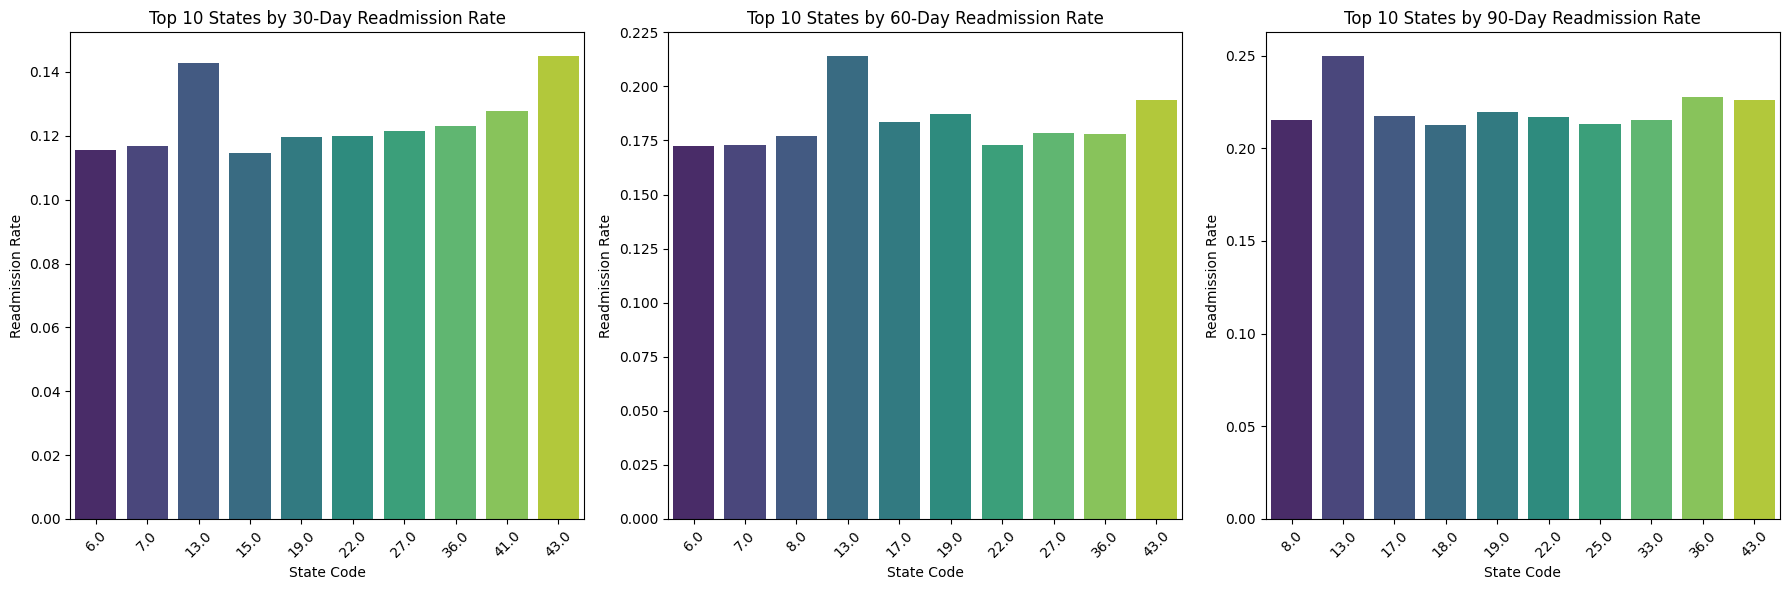


Analyzing Readmission Rate by Race Code...


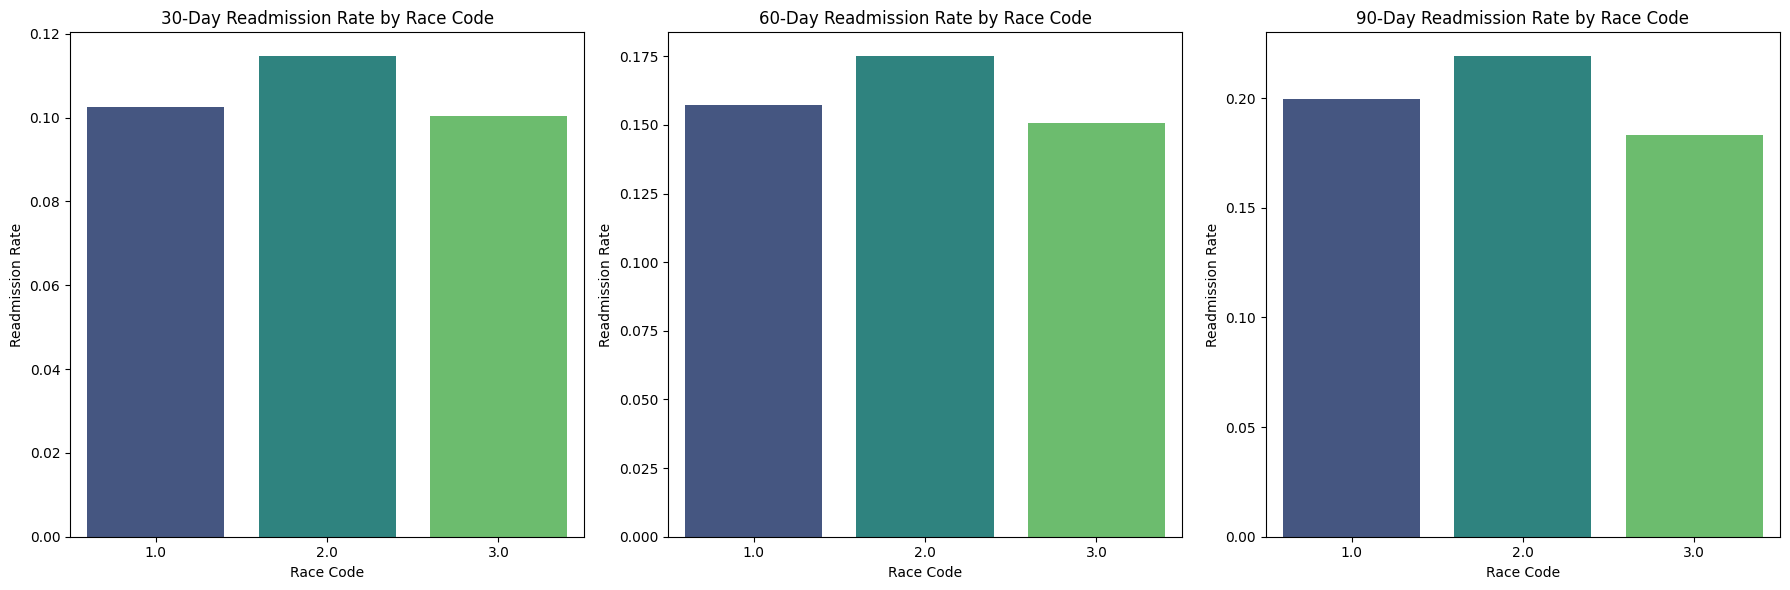

In [ ]:
# ========================================
# 📌 Geographic and Demographic Readmission Analysis
# ========================================

# Analyze Readmission Rate by State Code
print("Analyzing Readmission Rate by State Code...")
readmission_by_state_30 = df.groupby('SP_STATE_CODE')['READMIT_30'].mean().sort_values(ascending=False).reset_index()
readmission_by_state_60 = df.groupby('SP_STATE_CODE')['READMIT_60'].mean().sort_values(ascending=False).reset_index()
readmission_by_state_90 = df.groupby('SP_STATE_CODE')['READMIT_90'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='SP_STATE_CODE', y='READMIT_30', data=readmission_by_state_30.head(10), palette='viridis')
plt.title('Top 10 States by 30-Day Readmission Rate')
plt.xlabel('State Code')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.barplot(x='SP_STATE_CODE', y='READMIT_60', data=readmission_by_state_60.head(10), palette='viridis')
plt.title('Top 10 States by 60-Day Readmission Rate')
plt.xlabel('State Code')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.barplot(x='SP_STATE_CODE', y='READMIT_90', data=readmission_by_state_90.head(10), palette='viridis')
plt.title('Top 10 States by 90-Day Readmission Rate')
plt.xlabel('State Code')
plt.ylabel('Readmission Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Analyze Readmission Rate by Race Code
print("\nAnalyzing Readmission Rate by Race Code...")
readmission_by_race_30 = df.groupby('BENE_RACE_CD')['READMIT_30'].mean().sort_values(ascending=False).reset_index()
readmission_by_race_60 = df.groupby('BENE_RACE_CD')['READMIT_60'].mean().sort_values(ascending=False).reset_index()
readmission_by_race_90 = df.groupby('BENE_RACE_CD')['READMIT_90'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.barplot(x='BENE_RACE_CD', y='READMIT_30', data=readmission_by_race_30, palette='viridis')
plt.title('30-Day Readmission Rate by Race Code')
plt.xlabel('Race Code')
plt.ylabel('Readmission Rate')

plt.subplot(1, 3, 2)
sns.barplot(x='BENE_RACE_CD', y='READMIT_60', data=readmission_by_race_60, palette='viridis')
plt.title('60-Day Readmission Rate by Race Code')
plt.xlabel('Race Code')
plt.ylabel('Readmission Rate')

plt.subplot(1, 3, 3)
sns.barplot(x='BENE_RACE_CD', y='READMIT_90', data=readmission_by_race_90, palette='viridis')
plt.title('90-Day Readmission Rate by Race Code')
plt.xlabel('Race Code')
plt.ylabel('Readmission Rate')

plt.tight_layout()
plt.show()


# Note: Analyzing readmission by BENE_COUNTY_CD might result in a very large number of bars
# due to the high cardinality of county codes. Consider analyzing top/bottom counties
# or grouping counties by region if needed for a more interpretable visualization.
# For now, we will skip a detailed county-level plot due to the potential complexity.

## Model Summary: Readmission Prediction and Cost Estimation

This notebook demonstrates a workflow for predicting patient readmissions within 30, 60, and 90 days and estimating the associated costs.

**1. Data Loading and Preparation:**

- Loaded beneficiary summary data (`bene08`, `bene09`, `bene10`) and inpatient/outpatient claims data (`inpatient`, `outpatient`) for the years 2008-2010.
- Combined the beneficiary data longitudinally to have one row per beneficiary per year.
- Converted chronic condition indicators to binary (1/0).
- Merged beneficiary and claims data based on `DESYNPUF_ID`, keeping the first record for each patient.
- Engineered features including total reimbursement, beneficiary responsibility, and patient yearly payment amounts, as well as ratios of these by claim type.
- Calculated readmission flags for 30, 60, and 90 days based on inpatient admission dates.
- Handled missing values, primarily filling missing outpatient claim IDs with a placeholder and leaving missing outpatient dates as NaT.
- Corrected outliers in numerical features using capping at the 95th percentile.

**2. Exploratory Data Analysis (EDA):**

- Visualized the distribution of readmission flags for each window, showing the class imbalance.
- Analyzed readmission rates by age group, showing a general trend of increasing readmission rates with age.
- Analyzed readmission rates by chronic condition, identifying conditions associated with higher readmission risks (e.g., SP_STRKETIA, SP_COPD, SP_CHRNKIDN).
- Analyzed readmission rates by state code and race code, highlighting variations across these demographic and geographic factors.

**3. Feature Selection and Preprocessing:**

- Defined features (X) and target variables (y) for the 30, 60, and 90-day readmission prediction tasks.
- Separated numerical and categorical features.
- Created a preprocessing pipeline using `ColumnTransformer`:
    - Numerical features were imputed with the mean and scaled using `StandardScaler`.
    - Categorical features (although none were identified after initial cleaning and feature selection) would be one-hot encoded.
- Split the data into training and testing sets using `GroupShuffleSplit` to prevent data leakage by keeping all records for a given patient in either the train or test set.

**4. Model Training:**

- Trained separate classification models for each readmission window (30, 60, and 90 days) using:
    - RandomForestClassifier with `class_weight='balanced'` to address class imbalance.
    - XGBClassifier.

**5. Prediction:**

- Generated predictions (binary class and probability) on the test set for each trained model.

**6. Evaluation:**

- Evaluated model performance using:
    - `classification_report`: Providing precision, recall, and F1-score.
    - `roc_auc_score`: Calculating the Area Under the Receiver Operating Characteristic Curve.
    - `confusion_matrix`: Showing the counts of true positives, true negatives, false positives, and false negatives.
- The evaluation metrics provide insights into how well each model performs in predicting readmissions for different time windows. Given the class imbalance, metrics beyond accuracy (like precision, recall, F1-score, and AUC) are crucial for a comprehensive assessment.

**7. Cost Estimation:**

- Estimated the cost associated with predicted readmissions, focusing on cancer patients as an example, and also for the entire test set.
- The cost was simplified as the `TOTAL_REIMB` for predicted readmissions.
- Calculated the estimated total cost and average cost per predicted readmission.
- This step provides a business-relevant metric by translating model predictions into potential financial impact.

**8. Model Saving and Loading:**

- Saved the trained classification models using `joblib` to allow for later use without retraining.
- Demonstrated loading the saved models.

**9. Individual Patient Prediction:**

- Created a function `predict_readmission_by_id` to predict readmission for a specific patient by inputting their `DESYNPUF_ID`.
- This function retrieves the patient's data, preprocesses it, and uses the loaded models to provide predictions and probabilities for each readmission window and model type.

**Overall:**

This analysis provides a framework for predicting patient readmissions and understanding their associated costs. The models trained can help identify patients at higher risk of readmission, allowing for targeted interventions to potentially improve patient outcomes and reduce healthcare expenditures. Further steps could involve hyperparameter tuning, exploring more advanced modeling techniques, incorporating additional relevant data, and refining the cost estimation model.

# Task
Preprocess the `drug_concept` dataset by performing sanity checks, EDA, missing value treatment, outlier treatment, duplicate and garbage value treatment, normalization, and encoding.

## Data sanity check

### Subtask:
Examine the data types, look for inconsistencies, and understand the basic structure of the `drug_concept` dataframe.


**Reasoning**:
The first step is to examine the basic structure and content of the `drug_concept` dataframe, which includes displaying the head, checking data types, and getting descriptive statistics for both numerical and object columns.



In [ ]:
# Display the first few rows
print("First 5 rows of drug_concept:")
display(drug_concept.head())

# Print data types
print("\nData types of drug_concept columns:")
print(drug_concept.info())

# Generate descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(drug_concept.describe())

# Generate descriptive statistics for object columns
print("\nDescriptive statistics for object columns:")
display(drug_concept.describe(include='object'))

First 5 rows of drug_concept:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,STOP_REASON,REFILLS,QUANTITY,DAYS_SUPPLY,SIG,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,ROUTE_SOURCE_VALUE,DOSE_UNIT_SOURCE_VALUE,CONCEPT_ID,CONCEPT_NAME,DOMAIN_ID,VOCABULARY_ID,CONCEPT_CLASS_ID,STANDARD_CONCEPT,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE,INVALID_REASON
0,26318,573,40213160,1960-04-09,1960-04-09,1960-04-09,1960-04-09,1960-04-09,581452,NaN,0,0,0,NaN,0,0,0,38004.0,0,10,40213160,NaN,NaN,40213160.0,"poliovirus vaccine, inactivated",Drug,CVX,CVX,S,10,12/1/2008,12/31/2099,NaN
1,60926,1332,40213198,2010-10-06,2010-10-06,2010-10-06,2010-10-06,2010-10-06,581452,NaN,0,0,0,NaN,0,0,0,88400.0,0,133,40213198,NaN,NaN,40213198.0,"pneumococcal conjugate vaccine, 13 valent",Drug,CVX,CVX,S,133,10/15/2009,12/31/2099,NaN
2,26418,576,40213260,2017-10-25,2017-10-25,2017-10-25,2017-10-25,2017-10-25,581452,NaN,0,0,0,NaN,0,0,0,38145.0,0,121,40213260,NaN,NaN,40213260.0,"zoster vaccine, live",Drug,CVX,CVX,S,121,12/1/2008,12/31/2099,NaN
3,54785,4550,1118084,2000-11-13,2000-11-13,2000-11-13,2000-11-13,NaT,38000177,NaN,0,0,0,NaN,0,0,0,303185.0,0,25152531,44923712,NaN,NaN,44923712.0,celecoxib 200 MG Oral Capsule [Celebrex],Drug,NDC,11-digit NDC,NaN,25152531,1/1/2000,12/31/2099,NaN
4,47027,3895,40162522,1982-03-30,1982-03-30,1982-03-30,1982-03-30,NaT,38000177,NaN,0,0,0,NaN,0,0,0,259023.0,0,857005,40162522,NaN,NaN,40162522.0,Acetaminophen 325 MG / Hydrocodone Bitartrate ...,Drug,RxNorm,Clinical Drug,S,857005,8/2/2009,12/31/2099,NaN



Data types of drug_concept columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67707 entries, 0 to 67706
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DRUG_EXPOSURE_ID              67707 non-null  int64         
 1   PERSON_ID                     67707 non-null  int64         
 2   DRUG_CONCEPT_ID               67707 non-null  int64         
 3   DRUG_EXPOSURE_START_DATE      67707 non-null  datetime64[ns]
 4   DRUG_EXPOSURE_START_DATETIME  67707 non-null  datetime64[ns]
 5   DRUG_EXPOSURE_END_DATE        67707 non-null  datetime64[ns]
 6   DRUG_EXPOSURE_END_DATETIME    67707 non-null  datetime64[ns]
 7   VERBATIM_END_DATE             61944 non-null  datetime64[ns]
 8   DRUG_TYPE_CONCEPT_ID          67707 non-null  int64         
 9   STOP_REASON                   0 non-null      float64       
 10  REFILLS                       67707 non-null  int64      

,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,STOP_REASON,REFILLS,QUANTITY,DAYS_SUPPLY,SIG,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,ROUTE_SOURCE_VALUE,DOSE_UNIT_SOURCE_VALUE,CONCEPT_ID,INVALID_REASON
count,67707.000000,67707.000000,6.770700e+04,67707,67707,67707,67707,61944,6.770700e+04,0.0,67707.0,67707.0,67707.000000,0.0,67707.0,67707.0,67707.0,67187.000000,67707.0,6.770700e+04,6.770700e+04,0.0,0.0,6.767200e+04,0.0
mean,65610.739791,2650.860029,2.352313e+07,1987-01-03 09:01:39.375249216,1987-01-03 09:01:39.375249216,1987-02-05 16:09:22.754220352,1987-02-05 16:09:22.754220352,1986-04-03 22:52:18.318481216,2.379137e+07,NaN,0.0,0.0,33.297030,NaN,0.0,0.0,0.0,176276.552220,0.0,1.080188e+07,2.527630e+07,NaN,NaN,2.527950e+07,NaN
min,1.000000,1.000000,7.820470e+05,1909-05-17 00:00:00,1909-05-17 00:00:00,1909-05-31 00:00:00,1909-05-31 00:00:00,1909-05-31 00:00:00,5.814520e+05,NaN,0.0,0.0,0.000000,NaN,0.0,0.0,0.0,1.000000,0.0,1.000000e+01,7.820470e+05,NaN,NaN,7.820470e+05,NaN
25%,22013.500000,1333.000000,1.539411e+06,1971-07-14 12:00:00,1971-07-14 12:00:00,1971-08-11 00:00:00,1971-08-11 00:00:00,1970-09-05 00:00:00,5.814520e+05,NaN,0.0,0.0,0.000000,NaN,0.0,0.0,0.0,88415.500000,0.0,1.130000e+02,1.713671e+06,NaN,NaN,1.713671e+06,NaN
50%,44093.000000,2661.000000,1.913387e+07,1988-09-06 00:00:00,1988-09-06 00:00:00,1988-11-15 00:00:00,1988-11-15 00:00:00,1987-01-23 00:00:00,3.800018e+07,NaN,0.0,0.0,7.000000,NaN,0.0,0.0,0.0,176418.000000,0.0,2.824640e+05,4.016502e+07,NaN,NaN,4.016502e+07,NaN
75%,82885.000000,3956.000000,4.021323e+07,2005-03-28 00:00:00,2005-03-28 00:00:00,2005-05-05 12:00:00,2005-05-05 12:00:00,2004-07-20 00:00:00,3.800018e+07,NaN,0.0,0.0,14.000000,NaN,0.0,0.0,0.0,263049.000000,0.0,5.622510e+05,4.021323e+07,NaN,NaN,4.021323e+07,NaN
max,243409.000000,5343.000000,4.627592e+07,2019-07-01 00:00:00,2019-07-01 00:00:00,2019-07-01 00:00:00,2019-07-01 00:00:00,2019-07-01 00:00:00,3.800018e+07,NaN,0.0,0.0,20608.000000,NaN,0.0,0.0,0.0,355951.000000,0.0,7.811789e+08,4.627592e+07,NaN,NaN,4.627592e+07,NaN
std,62403.631884,1534.317116,1.712306e+07,NaN,NaN,NaN,NaN,NaN,1.816012e+07,NaN,0.0,0.0,321.513936,NaN,0.0,0.0,0.0,102044.622704,0.0,8.695927e+07,1.697593e+07,NaN,NaN,1.697973e+07,NaN



Descriptive statistics for object columns:


,CONCEPT_NAME,DOMAIN_ID,VOCABULARY_ID,CONCEPT_CLASS_ID,STANDARD_CONCEPT,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE
count,67672,67672,67672,67672,64978,67672,67672,67672
unique,112,1,3,10,1,112,40,1
top,Acetaminophen 325 MG Oral Tablet,Drug,RxNorm,Clinical Drug,S,313782,12/1/2008,12/31/2099
freq,9365,67672,39268,36218,64978,9365,25257,67672


**Reasoning**:
To complete the subtask of examining the basic structure of the `drug_concept` dataframe, I need to check the number of unique values in each column. This helps identify potential ID columns and understand the cardinality of categorical features.



In [ ]:
# Check the number of unique values per column
print("\nNumber of unique values per column:")
print(drug_concept.nunique())


Number of unique values per column:
DRUG_EXPOSURE_ID                63323
PERSON_ID                        2694
DRUG_CONCEPT_ID                   113
DRUG_EXPOSURE_START_DATE        23954
DRUG_EXPOSURE_START_DATETIME    23954
DRUG_EXPOSURE_END_DATE          24021
DRUG_EXPOSURE_END_DATETIME      24021
VERBATIM_END_DATE               23426
DRUG_TYPE_CONCEPT_ID                2
STOP_REASON                         0
REFILLS                             1
QUANTITY                            1
DAYS_SUPPLY                       273
SIG                                 0
ROUTE_CONCEPT_ID                    1
LOT_NUMBER                          1
PROVIDER_ID                         1
VISIT_OCCURRENCE_ID             55995
VISIT_DETAIL_ID                     1
DRUG_SOURCE_VALUE                 113
DRUG_SOURCE_CONCEPT_ID            113
ROUTE_SOURCE_VALUE                  0
DOSE_UNIT_SOURCE_VALUE              0
CONCEPT_ID                        112
CONCEPT_NAME                      112
DOMAIN_ID    

## Exploratory data analysis (eda)

### Subtask:
Visualize key distributions and relationships within the data to gain insights. This could include looking at the frequency of different drug concepts, domains, or concept classes.


**Reasoning**:
Visualize the distributions of key categorical and numerical columns to understand their value frequencies and patterns, as requested by the subtask instructions.



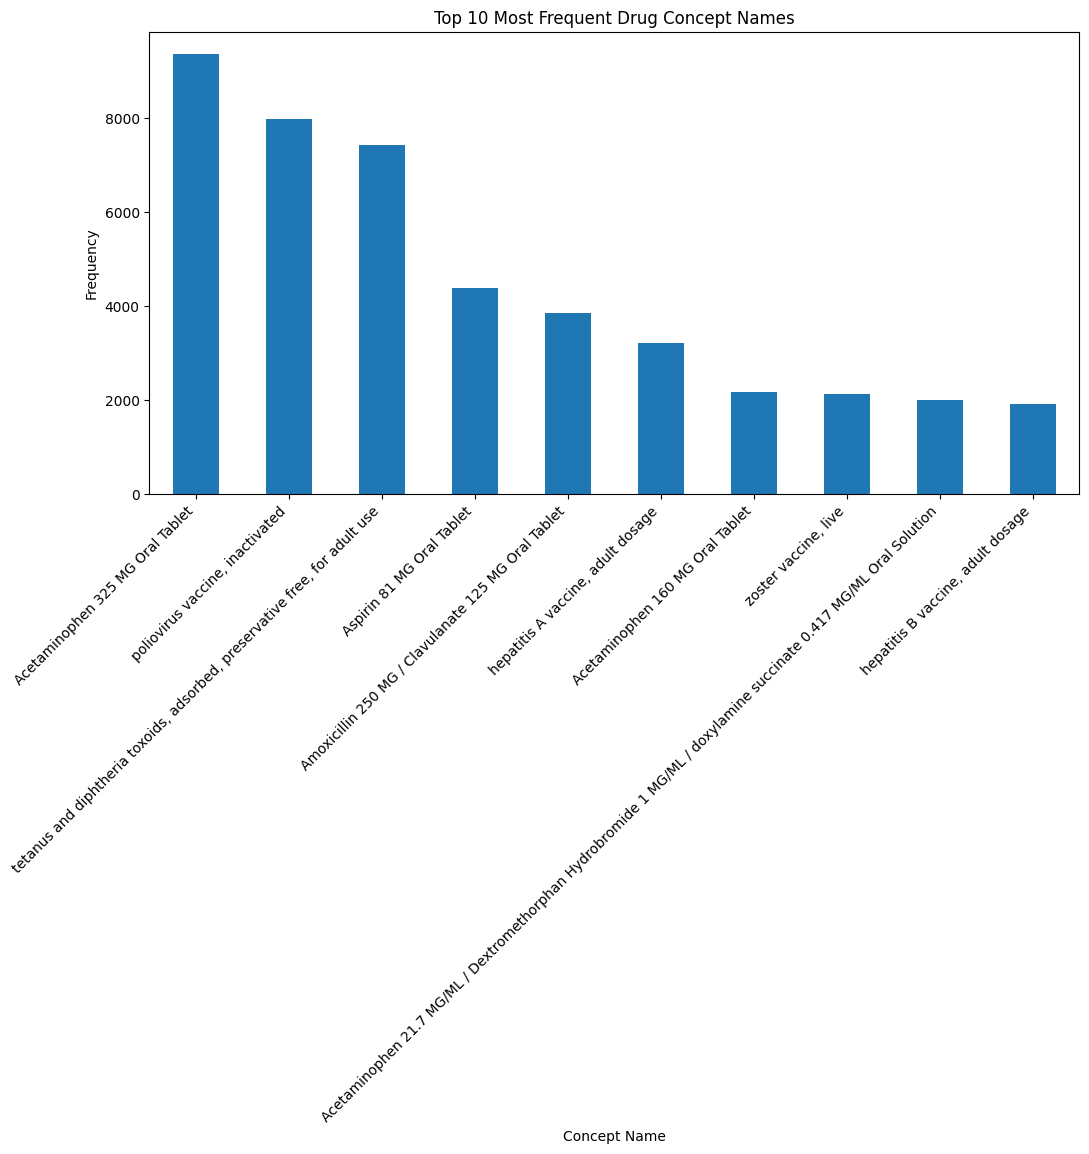

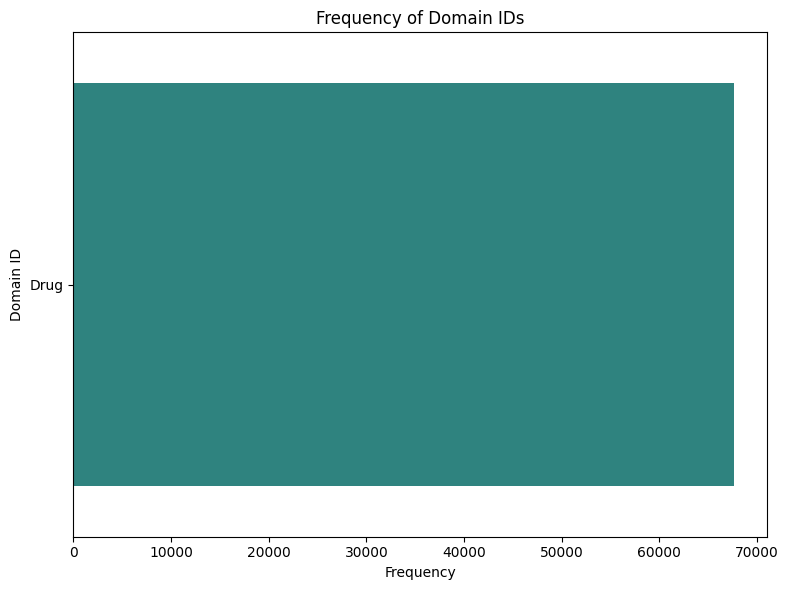

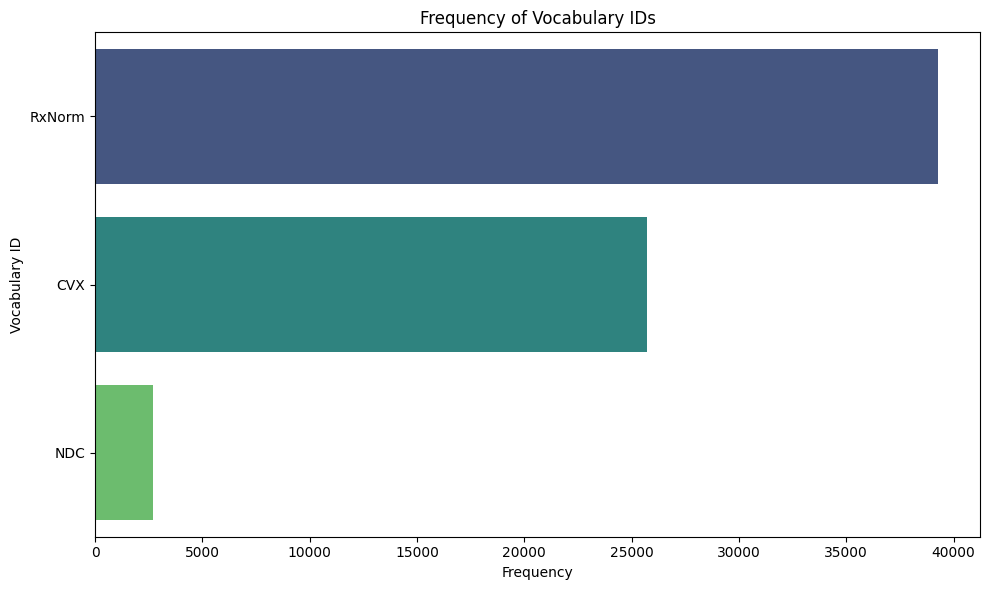

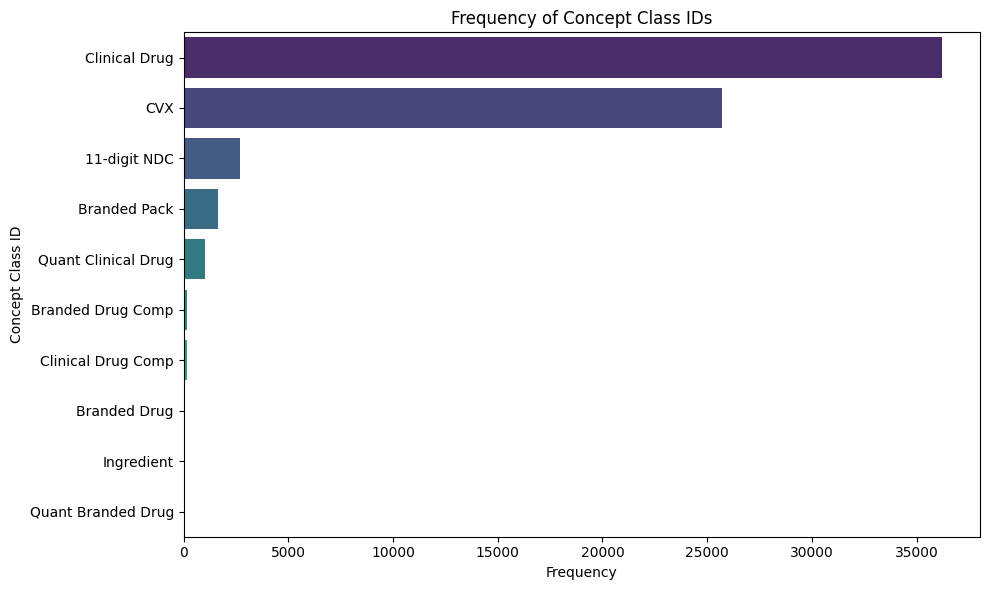

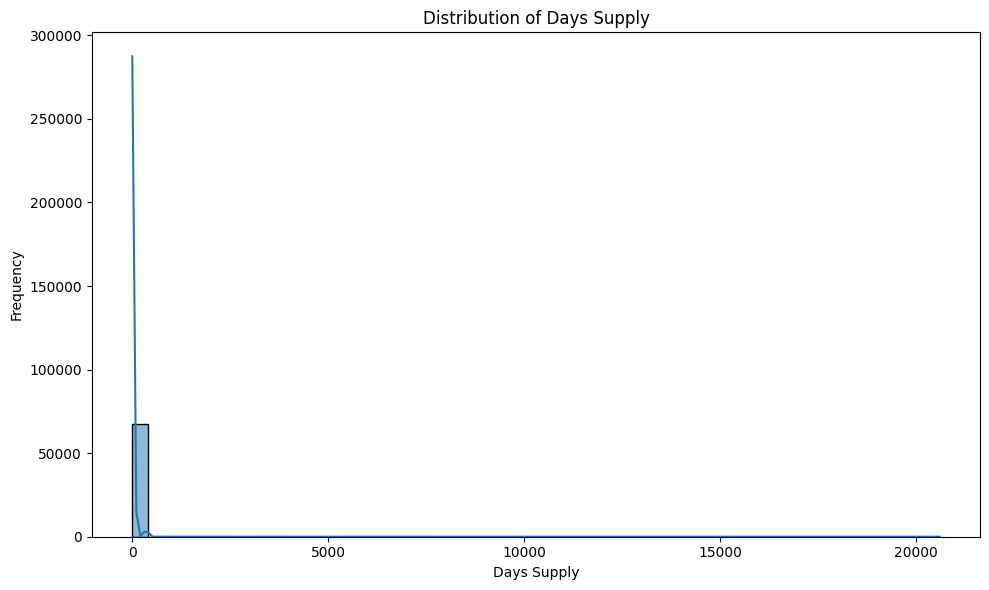

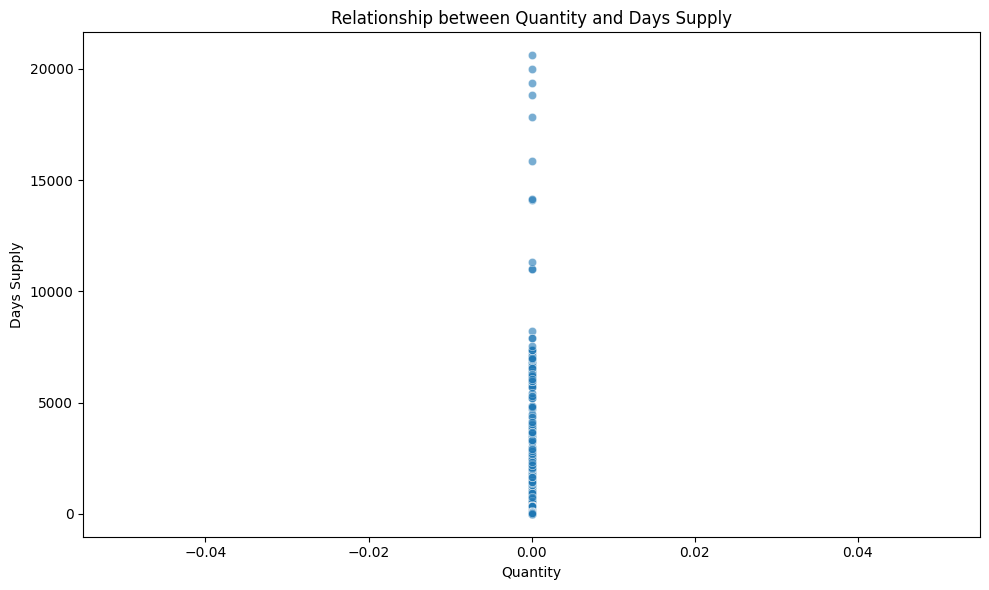

In [ ]:
# 1. Visualize the frequency of the top 10 most frequent CONCEPT_NAME values
plt.figure(figsize=(12, 6))
drug_concept['CONCEPT_NAME'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Top 10 Most Frequent Drug Concept Names')
plt.xlabel('Concept Name')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Visualize the frequency of DOMAIN_ID values
plt.figure(figsize=(8, 6))
sns.countplot(y='DOMAIN_ID', data=drug_concept, order=drug_concept['DOMAIN_ID'].value_counts().index, palette='viridis')
plt.title('Frequency of Domain IDs')
plt.xlabel('Frequency')
plt.ylabel('Domain ID')
plt.tight_layout()
plt.show()

# 3. Visualize the frequency of VOCABULARY_ID values
plt.figure(figsize=(10, 6))
sns.countplot(y='VOCABULARY_ID', data=drug_concept, order=drug_concept['VOCABULARY_ID'].value_counts().index, palette='viridis')
plt.title('Frequency of Vocabulary IDs')
plt.xlabel('Frequency')
plt.ylabel('Vocabulary ID')
plt.tight_layout()
plt.show()

# 4. Visualize the frequency of CONCEPT_CLASS_ID values
plt.figure(figsize=(10, 6))
sns.countplot(y='CONCEPT_CLASS_ID', data=drug_concept, order=drug_concept['CONCEPT_CLASS_ID'].value_counts().index, palette='viridis')
plt.title('Frequency of Concept Class IDs')
plt.xlabel('Frequency')
plt.ylabel('Concept Class ID')
plt.tight_layout()
plt.show()

# 5. Visualize the distribution of DAYS_SUPPLY
plt.figure(figsize=(10, 6))
sns.histplot(drug_concept['DAYS_SUPPLY'].dropna(), bins=50, kde=True) # Drop NaNs for plotting
plt.title('Distribution of Days Supply')
plt.xlabel('Days Supply')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 6. Visualize the relationship between QUANTITY and DAYS_SUPPLY
# Filter out rows where both QUANTITY and DAYS_SUPPLY are 0 or missing for better visualization
plot_data = drug_concept[(drug_concept['QUANTITY'] > 0) | (drug_concept['DAYS_SUPPLY'] > 0)].dropna(subset=['QUANTITY', 'DAYS_SUPPLY'])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='QUANTITY', y='DAYS_SUPPLY', data=plot_data, alpha=0.6)
plt.title('Relationship between Quantity and Days Supply')
plt.xlabel('Quantity')
plt.ylabel('Days Supply')
plt.tight_layout()
plt.show()

## Missing value treatment

### Subtask:
Identify and handle missing values in the dataframe. This might involve imputation or dropping rows/columns depending on the extent and nature of missingness.


**Reasoning**:
Calculate and display the percentage of missing values for each column in the drug_concept DataFrame.



In [ ]:
# Calculate the percentage of missing values for each column
missing_percentage = drug_concept.isnull().sum() / len(drug_concept) * 100

# Print the percentage of missing values
print("Percentage of missing values per column:")
print(missing_percentage)

# Identify columns with a high percentage of missing values (e.g., > 75%)
high_missing_cols = missing_percentage[missing_percentage > 75].index.tolist()
print(f"\nColumns with more than 75% missing values: {high_missing_cols}")

# Identify columns with 0 non-null values (100% missing)
empty_cols = missing_percentage[missing_percentage == 100].index.tolist()
print(f"Columns with 100% missing values: {empty_cols}")

# Strategy for handling missing values:
# Drop columns with 100% missing values as they contain no information.
# For columns with less than 100% missing values, consider imputation or further investigation
# based on the column's relevance and the extent of missingness.

# Drop columns with 100% missing values
drug_concept_cleaned = drug_concept.drop(columns=empty_cols)
print(f"\nDropped columns with 100% missing values: {empty_cols}")

# Re-calculate and print the percentage of missing values after dropping empty columns
print("\nPercentage of missing values per column after dropping empty columns:")
missing_percentage_cleaned = drug_concept_cleaned.isnull().sum() / len(drug_concept_cleaned) * 100
print(missing_percentage_cleaned)

# For other columns with missing values (e.g., less than 100%), we can decide on imputation strategies
# For example, impute numerical columns with the mean/median, and categorical columns with mode or a placeholder.
# Based on the `info()` and `describe()` from the sanity check,
# numerical columns like DAYS_SUPPLY have NaNs, and object columns like DRUG_EXPOSURE_END_DATETIME, VERBATIM_END_DATE, ROUTE_SOURCE_VALUE, DOSE_UNIT_SOURCE_VALUE, CONCEPT_ID, CONCEPT_NAME, DOMAIN_ID, VOCABULARY_ID, CONCEPT_CLASS_ID, STANDARD_CONCEPT, CONCEPT_CODE, VALID_START_DATE, VALID_END_DATE, INVALID_REASON have NaNs.

# Let's impute numerical column 'DAYS_SUPPLY' with the median.
if 'DAYS_SUPPLY' in drug_concept_cleaned.columns:
    median_days_supply = drug_concept_cleaned['DAYS_SUPPLY'].median()
    drug_concept_cleaned['DAYS_SUPPLY'] = drug_concept_cleaned['DAYS_SUPPLY'].fillna(median_days_supply)
    print(f"\nImputed 'DAYS_SUPPLY' with median value: {median_days_supply}")

# Impute object columns that are relevant for downstream analysis (excluding IDs and dates for now)
# For example, impute missing Concept-related fields with a placeholder 'Unknown'
concept_related_cols = ['CONCEPT_ID', 'CONCEPT_NAME', 'DOMAIN_ID', 'VOCABULARY_ID', 'CONCEPT_CLASS_ID', 'STANDARD_CONCEPT', 'CONCEPT_CODE', 'VALID_START_DATE', 'VALID_END_DATE', 'INVALID_REASON']
for col in concept_related_cols:
    if col in drug_concept_cleaned.columns:
        drug_concept_cleaned[col] = drug_concept_cleaned[col].fillna('Unknown')
        print(f"Imputed missing values in '{col}' with 'Unknown'")

# Re-calculate and print the percentage of missing values after imputation
print("\nPercentage of missing values per column after imputation:")
missing_percentage_final = drug_concept_cleaned.isnull().sum() / len(drug_concept_cleaned) * 100
print(missing_percentage_final)

Percentage of missing values per column:
DRUG_EXPOSURE_ID                  0.000000
PERSON_ID                         0.000000
DRUG_CONCEPT_ID                   0.000000
DRUG_EXPOSURE_START_DATE          0.000000
DRUG_EXPOSURE_START_DATETIME      0.000000
DRUG_EXPOSURE_END_DATE            0.000000
DRUG_EXPOSURE_END_DATETIME        0.000000
VERBATIM_END_DATE                 8.511675
DRUG_TYPE_CONCEPT_ID              0.000000
STOP_REASON                     100.000000
REFILLS                           0.000000
QUANTITY                          0.000000
DAYS_SUPPLY                       0.000000
SIG                             100.000000
ROUTE_CONCEPT_ID                  0.000000
LOT_NUMBER                        0.000000
PROVIDER_ID                       0.000000
VISIT_OCCURRENCE_ID               0.768015
VISIT_DETAIL_ID                   0.000000
DRUG_SOURCE_VALUE                 0.000000
DRUG_SOURCE_CONCEPT_ID            0.000000
ROUTE_SOURCE_VALUE              100.000000
DOSE_UNIT_SOU

**Reasoning**:
Continue handling the remaining missing values after dropping empty columns and imputing some columns, and then print the missing percentages again to confirm the changes.



In [ ]:
# Continue handling remaining missing values.
# Based on the previous output, 'VERBATIM_END_DATE' and 'VISIT_OCCURRENCE_ID' still have missing values.

# For 'VERBATIM_END_DATE' (datetime type), imputing with a specific date or the mode might be appropriate,
# or leaving as NaT depending on downstream use. Let's impute with the mode for now, as it's a date column.
if 'VERBATIM_END_DATE' in drug_concept_cleaned.columns and drug_concept_cleaned['VERBATIM_END_DATE'].isnull().sum() > 0:
    mode_verbatim_end_date = drug_concept_cleaned['VERBATIM_END_DATE'].mode()[0] # mode() can return multiple values, take the first
    drug_concept_cleaned['VERBATIM_END_DATE'] = drug_concept_cleaned['VERBATIM_END_DATE'].fillna(mode_verbatim_end_date)
    print(f"Imputed missing values in 'VERBATIM_END_DATE' with mode: {mode_verbatim_end_date}")

# For 'VISIT_OCCURRENCE_ID' (numerical/float type), imputing with a placeholder (e.g., 0 or -1) or the mode might be suitable.
# Let's impute with 0 as it's an ID and 0 is not a valid ID in the sample data.
if 'VISIT_OCCURRENCE_ID' in drug_concept_cleaned.columns and drug_concept_cleaned['VISIT_OCCURRENCE_ID'].isnull().sum() > 0:
    drug_concept_cleaned['VISIT_OCCURRENCE_ID'] = drug_concept_cleaned['VISIT_OCCURRENCE_ID'].fillna(0)
    print("Imputed missing values in 'VISIT_OCCURRENCE_ID' with 0")


# Re-calculate and print the percentage of missing values after handling remaining NaNs
print("\nPercentage of missing values per column after handling remaining NaNs:")
missing_percentage_final = drug_concept_cleaned.isnull().sum() / len(drug_concept_cleaned) * 100
print(missing_percentage_final)

Imputed missing values in 'VERBATIM_END_DATE' with mode: 1972-04-22 00:00:00
Imputed missing values in 'VISIT_OCCURRENCE_ID' with 0

Percentage of missing values per column after handling remaining NaNs:
DRUG_EXPOSURE_ID                0.0
PERSON_ID                       0.0
DRUG_CONCEPT_ID                 0.0
DRUG_EXPOSURE_START_DATE        0.0
DRUG_EXPOSURE_START_DATETIME    0.0
DRUG_EXPOSURE_END_DATE          0.0
DRUG_EXPOSURE_END_DATETIME      0.0
VERBATIM_END_DATE               0.0
DRUG_TYPE_CONCEPT_ID            0.0
REFILLS                         0.0
QUANTITY                        0.0
DAYS_SUPPLY                     0.0
ROUTE_CONCEPT_ID                0.0
LOT_NUMBER                      0.0
PROVIDER_ID                     0.0
VISIT_OCCURRENCE_ID             0.0
VISIT_DETAIL_ID                 0.0
DRUG_SOURCE_VALUE               0.0
DRUG_SOURCE_CONCEPT_ID          0.0
CONCEPT_ID                      0.0
CONCEPT_NAME                    0.0
DOMAIN_ID                       0.0
VOCA

## Outlier treatment

### Subtask:
Identify and handle outliers in numerical columns, possibly using techniques like capping or removal.


**Reasoning**:
Identify and visualize outliers in numerical columns using box plots.



Numerical columns in cleaned dataframe: ['DRUG_EXPOSURE_ID', 'PERSON_ID', 'DRUG_CONCEPT_ID', 'DRUG_TYPE_CONCEPT_ID', 'REFILLS', 'QUANTITY', 'DAYS_SUPPLY', 'ROUTE_CONCEPT_ID', 'LOT_NUMBER', 'PROVIDER_ID', 'VISIT_OCCURRENCE_ID', 'VISIT_DETAIL_ID', 'DRUG_SOURCE_VALUE', 'DRUG_SOURCE_CONCEPT_ID']


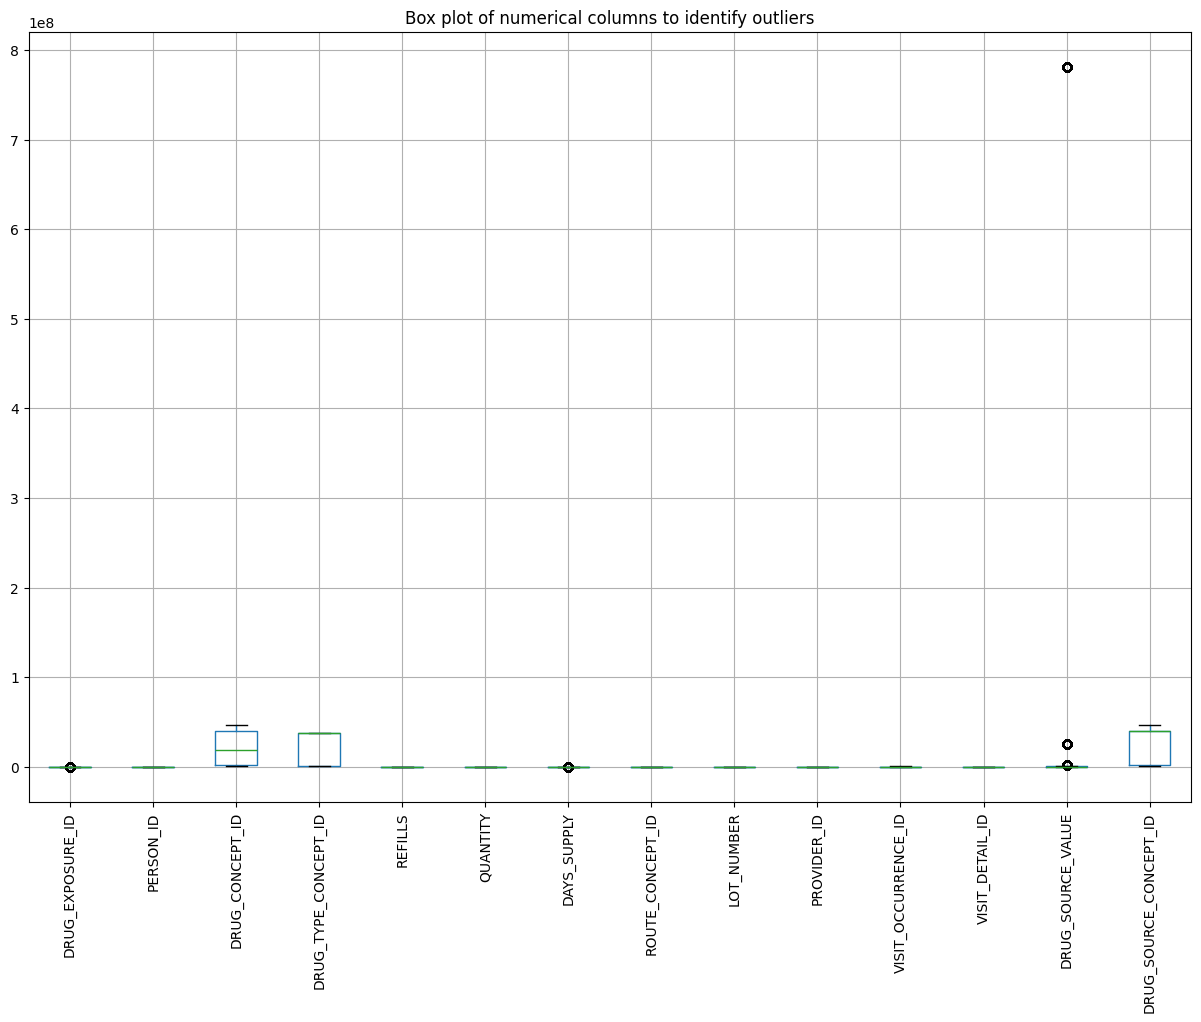


Descriptive statistics for numerical columns before outlier treatment:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID
count,67707.000000,67707.000000,6.770700e+04,6.770700e+04,67707.0,67707.0,67707.000000,67707.0,67707.0,67707.0,67707.000000,67707.0,6.770700e+04,6.770700e+04
mean,65610.739791,2650.860029,2.352313e+07,2.379137e+07,0.0,0.0,33.297030,0.0,0.0,0.0,174922.721639,0.0,1.080188e+07,2.527630e+07
std,62403.631884,1534.317116,1.712306e+07,1.816012e+07,0.0,0.0,321.513936,0.0,0.0,0.0,102810.256530,0.0,8.695927e+07,1.697593e+07
min,1.000000,1.000000,7.820470e+05,5.814520e+05,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.000000e+01,7.820470e+05
25%,22013.500000,1333.000000,1.539411e+06,5.814520e+05,0.0,0.0,0.000000,0.0,0.0,0.0,86450.500000,0.0,1.130000e+02,1.713671e+06
50%,44093.000000,2661.000000,1.913387e+07,3.800018e+07,0.0,0.0,7.000000,0.0,0.0,0.0,174425.000000,0.0,2.824640e+05,4.016502e+07
75%,82885.000000,3956.000000,4.021323e+07,3.800018e+07,0.0,0.0,14.000000,0.0,0.0,0.0,262155.000000,0.0,5.622510e+05,4.021323e+07
max,243409.000000,5343.000000,4.627592e+07,3.800018e+07,0.0,0.0,20608.000000,0.0,0.0,0.0,355951.000000,0.0,7.811789e+08,4.627592e+07


In [ ]:
# Identify numerical columns in the cleaned dataframe
numerical_cols_cleaned = drug_concept_cleaned.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns in cleaned dataframe:", numerical_cols_cleaned)

# Visualize the distribution of numerical columns using box plots to identify outliers
plt.figure(figsize=(15, 10))
drug_concept_cleaned[numerical_cols_cleaned].boxplot()
plt.title('Box plot of numerical columns to identify outliers')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# Print descriptive statistics for numerical columns before outlier treatment
print("\nDescriptive statistics for numerical columns before outlier treatment:")
display(drug_concept_cleaned[numerical_cols_cleaned].describe())

**Reasoning**:
Based on the box plot and descriptive statistics, several numerical columns, particularly 'DAYS_SUPPLY', 'DRUG_SOURCE_VALUE', 'DRUG_SOURCE_CONCEPT_ID', 'DRUG_EXPOSURE_ID', 'PERSON_ID', 'DRUG_CONCEPT_ID', 'DRUG_TYPE_CONCEPT_ID', and 'VISIT_OCCURRENCE_ID', show extreme outliers. Capping is a suitable method to handle these outliers without removing data points. I will cap the values at the 95th percentile for these columns.



Capped outliers in 'DAYS_SUPPLY' at the 95th percentile (60.00)
Capped outliers in 'DRUG_SOURCE_VALUE' at the 95th percentile (1652673.00)
Capped outliers in 'DRUG_SOURCE_CONCEPT_ID' at the 95th percentile (44923712.00)
Capped outliers in 'DRUG_EXPOSURE_ID' at the 95th percentile (208683.80)
Capped outliers in 'PERSON_ID' at the 95th percentile (5065.00)
Capped outliers in 'DRUG_CONCEPT_ID' at the 95th percentile (40229134.00)
Capped outliers in 'DRUG_TYPE_CONCEPT_ID' at the 95th percentile (38000177.00)
Capped outliers in 'VISIT_OCCURRENCE_ID' at the 95th percentile (336584.60)


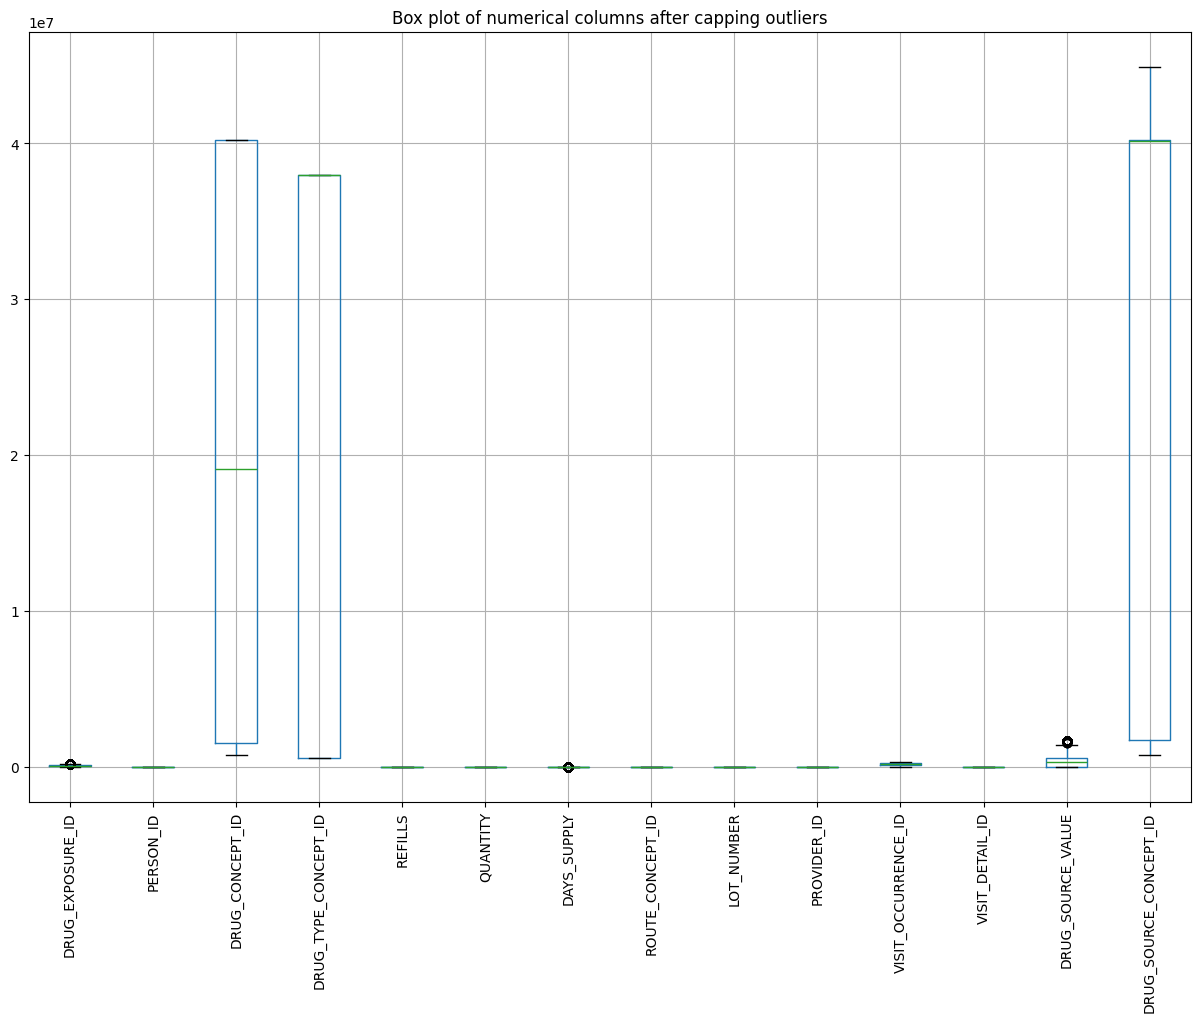


Descriptive statistics for numerical columns after outlier treatment:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID
count,67707.000000,67707.000000,6.770700e+04,6.770700e+04,67707.0,67707.0,67707.000000,67707.0,67707.0,67707.0,67707.000000,67707.0,6.770700e+04,6.770700e+04
mean,64771.833899,2643.838673,2.345065e+07,2.379137e+07,0.0,0.0,10.347010,0.0,0.0,0.0,174444.203119,0.0,3.747244e+05,2.526081e+07
std,60285.165380,1522.785306,1.703993e+07,1.816012e+07,0.0,0.0,15.296703,0.0,0.0,0.0,102024.070435,0.0,4.498197e+05,1.695743e+07
min,1.000000,1.000000,7.820470e+05,5.814520e+05,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.000000e+01,7.820470e+05
25%,22013.500000,1333.000000,1.539411e+06,5.814520e+05,0.0,0.0,0.000000,0.0,0.0,0.0,86450.500000,0.0,1.130000e+02,1.713671e+06
50%,44093.000000,2661.000000,1.913387e+07,3.800018e+07,0.0,0.0,7.000000,0.0,0.0,0.0,174425.000000,0.0,2.824640e+05,4.016502e+07
75%,82885.000000,3956.000000,4.021323e+07,3.800018e+07,0.0,0.0,14.000000,0.0,0.0,0.0,262155.000000,0.0,5.622510e+05,4.021323e+07
max,208683.800000,5065.000000,4.022913e+07,3.800018e+07,0.0,0.0,60.000000,0.0,0.0,0.0,336584.600000,0.0,1.652673e+06,4.492371e+07


In [ ]:
# Identify columns that appear to have outliers based on the box plot and descriptive statistics
outlier_cols = ['DAYS_SUPPLY', 'DRUG_SOURCE_VALUE', 'DRUG_SOURCE_CONCEPT_ID',
                'DRUG_EXPOSURE_ID', 'PERSON_ID', 'DRUG_CONCEPT_ID',
                'DRUG_TYPE_CONCEPT_ID', 'VISIT_OCCURRENCE_ID']

# Apply capping at the 95th percentile for the identified numerical columns
for col in outlier_cols:
    if col in drug_concept_cleaned.columns:
        upper_limit = drug_concept_cleaned[col].quantile(0.95)
        drug_concept_cleaned[col] = np.where(drug_concept_cleaned[col] > upper_limit, upper_limit, drug_concept_cleaned[col])
        print(f"Capped outliers in '{col}' at the 95th percentile ({upper_limit:.2f})")

# Visualize the distribution of numerical columns again using box plots after capping
plt.figure(figsize=(15, 10))
drug_concept_cleaned[numerical_cols_cleaned].boxplot()
plt.title('Box plot of numerical columns after capping outliers')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

# Print descriptive statistics for numerical columns after outlier treatment
print("\nDescriptive statistics for numerical columns after outlier treatment:")
display(drug_concept_cleaned[numerical_cols_cleaned].describe())

## Duplicate and garbage value treatment

### Subtask:
Identify and remove duplicate rows and handle any 'garbage' or nonsensical values that might be present.


**Reasoning**:
Check for and remove duplicate rows in the drug_concept_cleaned DataFrame.



In [ ]:
# Check for duplicate rows
print("Number of duplicate rows before dropping:", drug_concept_cleaned.duplicated().sum())

# Remove duplicate rows, keeping the first occurrence
drug_concept_cleaned = drug_concept_cleaned.drop_duplicates(keep='first')

# Print the shape before and after removing duplicates
print("Shape of DataFrame before dropping duplicates:", drug_concept.shape)
print("Shape of DataFrame after dropping duplicates:", drug_concept_cleaned.shape)

# Re-check for duplicate rows to confirm removal
print("\nNumber of duplicate rows after dropping:", drug_concept_cleaned.duplicated().sum())

Number of duplicate rows before dropping: 17
Shape of DataFrame before dropping duplicates: (67707, 33)
Shape of DataFrame after dropping duplicates: (67690, 28)

Number of duplicate rows after dropping: 0


**Reasoning**:
Examine relevant columns for any values that appear to be nonsensical or indicative of data entry errors ("garbage values").



In [ ]:
# Examine numerical columns for potentially 'garbage' values
# Although capping was applied, extremely low or negative values might still exist or
# indicate issues if they were outside the capping range or if capping wasn't applied uniformly.
print("\nDescriptive statistics for numerical columns after capping:")
display(drug_concept_cleaned.select_dtypes(include=np.number).describe())

# Examine object columns for potentially 'garbage' values
# Look for values that don't fit the expected categories or format.
# We can check the unique values for columns with relatively low cardinality.
object_cols_cleaned = drug_concept_cleaned.select_dtypes(include='object').columns.tolist()
print("\nUnique values in object columns (showing up to 20 unique values):")
for col in object_cols_cleaned:
    unique_values = drug_concept_cleaned[col].unique()
    print(f"\nColumn '{col}':")
    if len(unique_values) <= 20:
        print(unique_values)
    else:
        print(f"First 20 unique values: {unique_values[:20]}...")

# Specifically examine date columns (now object type after imputation with 'Unknown')
# Check if there are any 'Unknown' values or other non-date strings
date_cols_cleaned = ['DRUG_EXPOSURE_START_DATE', 'DRUG_EXPOSURE_START_DATETIME',
                     'DRUG_EXPOSURE_END_DATE', 'DRUG_EXPOSURE_END_DATETIME',
                     'VERBATIM_END_DATE', 'VALID_START_DATE', 'VALID_END_DATE']

print("\nChecking for 'Unknown' or non-date values in date columns:")
for col in date_cols_cleaned:
    if col in drug_concept_cleaned.columns:
        non_date_values = drug_concept_cleaned[col][~drug_concept_cleaned[col].apply(lambda x: isinstance(x, pd.Timestamp) or x == 'Unknown')].unique()
        if len(non_date_values) > 0:
            print(f"Column '{col}' has non-date values (excluding 'Unknown'): {non_date_values}")
        else:
            print(f"Column '{col}' contains only date values or 'Unknown'.")

# Further examine the 'Unknown' values in concept-related columns
concept_related_cols_cleaned = ['CONCEPT_ID', 'CONCEPT_NAME', 'DOMAIN_ID', 'VOCABULARY_ID',
                                'CONCEPT_CLASS_ID', 'STANDARD_CONCEPT', 'CONCEPT_CODE',
                                'VALID_START_DATE', 'VALID_END_DATE', 'INVALID_REASON']

print("\nCounts of 'Unknown' values in concept-related columns:")
for col in concept_related_cols_cleaned:
     if col in drug_concept_cleaned.columns:
        unknown_count = (drug_concept_cleaned[col] == 'Unknown').sum()
        print(f"Column '{col}': {unknown_count} 'Unknown' values")


Descriptive statistics for numerical columns after capping:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID
count,67690.000000,67690.000000,6.769000e+04,6.769000e+04,67690.0,67690.0,67690.000000,67690.0,67690.0,67690.0,67690.000000,67690.0,6.769000e+04,6.769000e+04
mean,64735.691139,2643.230610,2.344644e+07,2.379720e+07,0.0,0.0,10.349609,0.0,0.0,0.0,174403.482381,0.0,3.748185e+05,2.525706e+07
std,60249.573906,1522.492976,1.703999e+07,1.815868e+07,0.0,0.0,15.297745,0.0,0.0,0.0,102004.514114,0.0,4.498369e+05,1.695791e+07
min,1.000000,1.000000,7.820470e+05,5.814520e+05,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.000000e+01,7.820470e+05
25%,22009.250000,1332.000000,1.539411e+06,5.814520e+05,0.0,0.0,0.000000,0.0,0.0,0.0,86444.250000,0.0,1.130000e+02,1.713671e+06
50%,44084.500000,2661.000000,1.913387e+07,3.800018e+07,0.0,0.0,7.000000,0.0,0.0,0.0,174259.000000,0.0,2.824640e+05,4.016502e+07
75%,82756.750000,3956.000000,4.021323e+07,3.800018e+07,0.0,0.0,14.000000,0.0,0.0,0.0,262134.500000,0.0,5.622510e+05,4.021323e+07
max,208683.800000,5065.000000,4.022913e+07,3.800018e+07,0.0,0.0,60.000000,0.0,0.0,0.0,336584.600000,0.0,1.652673e+06,4.492371e+07



Unique values in object columns (showing up to 20 unique values):

Column 'CONCEPT_ID':
First 20 unique values: [40213160.0 40213198.0 40213260.0 44923712.0 40162522.0 19059056.0
 40213296.0 1127078.0 1127433.0 40229134.0 40213306.0 1713671.0 19133905.0
 40236824.0 40165015.0 40213227.0 40173590.0 1551192.0 19128065.0
 19006318.0]...

Column 'CONCEPT_NAME':
First 20 unique values: ['poliovirus vaccine, inactivated'
 'pneumococcal conjugate vaccine, 13 valent' 'zoster vaccine, live'
 'celecoxib 200 MG Oral Capsule [Celebrex]'
 'Acetaminophen 325 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet'
 'Aspirin 81 MG Oral Tablet' 'hepatitis A vaccine, adult dosage'
 'Acetaminophen 160 MG Oral Tablet' 'Acetaminophen 325 MG Oral Tablet'
 'Acetaminophen 21.7 MG/ML / Dextromethorphan Hydrobromide 1 MG/ML / doxylamine succinate 0.417 MG/ML Oral Solution'
 'hepatitis B vaccine, adult dosage'
 'Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet'
 'Penicillin V Potassium 500 MG Oral Tablet'
 'Phenazop

## Encoding

### Subtask:
Convert categorical features into a numerical format suitable for machine learning models (e.g., One-Hot Encoding).


**Reasoning**:
Identify categorical columns, instantiate OneHotEncoder, fit and transform the data, create a new DataFrame with encoded features, drop original categorical columns, concatenate with numerical columns, and display the head and shape.



In [ ]:
# 1. Identify the categorical columns in the drug_concept_cleaned DataFrame.
# Exclude the 'PERSON_ID', 'DRUG_EXPOSURE_ID' and date columns as they are not suitable for direct one-hot encoding.
# Also exclude columns that might have been imputed with 'Unknown' but are not truly categorical features,
# such as 'CONCEPT_ID', 'CONCEPT_CODE'.
# Based on the previous EDA and sanity checks, potential categorical columns (excluding IDs and dates) are:
# 'DOMAIN_ID', 'VOCABULARY_ID', 'CONCEPT_CLASS_ID', 'STANDARD_CONCEPT', 'CONCEPT_NAME', 'INVALID_REASON'
# Let's re-check the dtypes and unique values to be sure.

object_cols_cleaned = drug_concept_cleaned.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_cols_cleaned)

# Filter out ID and date columns
categorical_cols_to_encode = [col for col in object_cols_cleaned if col not in [
    'DRUG_EXPOSURE_ID', 'PERSON_ID', 'DRUG_EXPOSURE_START_DATE',
    'DRUG_EXPOSURE_START_DATETIME', 'DRUG_EXPOSURE_END_DATE',
    'DRUG_EXPOSURE_END_DATETIME', 'VERBATIM_END_DATE', 'VALID_START_DATE',
    'VALID_END_DATE', 'CONCEPT_ID', 'CONCEPT_CODE', 'DRUG_SOURCE_VALUE' # Exclude high cardinality/ID-like object cols
]]

print("\nCategorical columns selected for encoding:", categorical_cols_to_encode)

# 2. Instantiate a OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Use sparse_output=False for dense array output

# 3. Fit and transform the identified categorical columns
encoded_features = encoder.fit_transform(drug_concept_cleaned[categorical_cols_to_encode])

# 4. Create a new DataFrame with appropriate column names
# Get the new column names after one-hot encoding
encoded_feature_names = encoder.get_feature_names_out(categorical_cols_to_encode)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=drug_concept_cleaned.index)

# 5. Drop the original categorical columns from drug_concept_cleaned
drug_concept_numerical = drug_concept_cleaned.drop(columns=categorical_cols_to_encode)

# 6. Concatenate the original numerical columns and the new one-hot encoded categorical columns
drug_concept_preprocessed = pd.concat([drug_concept_numerical, encoded_df], axis=1)

# 7. Display the head and shape of the resulting DataFrame
print("\nPreprocessed DataFrame head after one-hot encoding:")
display(drug_concept_preprocessed.head())

print("\nShape of preprocessed DataFrame:", drug_concept_preprocessed.shape)

Object columns: ['CONCEPT_ID', 'CONCEPT_NAME', 'DOMAIN_ID', 'VOCABULARY_ID', 'CONCEPT_CLASS_ID', 'STANDARD_CONCEPT', 'CONCEPT_CODE', 'VALID_START_DATE', 'VALID_END_DATE']

Categorical columns selected for encoding: ['CONCEPT_NAME', 'DOMAIN_ID', 'VOCABULARY_ID', 'CONCEPT_CLASS_ID', 'STANDARD_CONCEPT']

Preprocessed DataFrame head after one-hot encoding:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,CONCEPT_ID,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE,CONCEPT_NAME_1 ML Atropine Sulfate 1 MG/ML Injection,CONCEPT_NAME_1 ML Epinephrine 1 MG/ML Injection,CONCEPT_NAME_1 ML Morphine Sulfate 5 MG/ML Injection,CONCEPT_NAME_1 ML medroxyprogesterone acetate 150 MG/ML Injection,CONCEPT_NAME_100 ML Propofol 10 MG/ML Injection,CONCEPT_NAME_12 HR Cefaclor 500 MG Extended Release Oral Tablet,CONCEPT_NAME_120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_168 HR Ethinyl Estradiol 0.00146 MG/HR / norelgestromin 0.00625 MG/HR Transdermal System,CONCEPT_NAME_2 ML Ondansetron 2 MG/ML Injection,CONCEPT_NAME_200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_21 DAY Ethinyl Estradiol 0.000625 MG/HR / Etonogestrel 0.005 MG/HR Vaginal Ring [NuvaRing],CONCEPT_NAME_24 HR Donepezil hydrochloride 10 MG / Memantine hydrochloride 28 MG Extended Release Oral Capsule,CONCEPT_NAME_3 ML Amiodarone hydrochloride 50 MG/ML Prefilled Syringe,CONCEPT_NAME_60 ACTUAT Fluticasone propionate 0.25 MG/ACTUAT / salmeterol 0.05 MG/ACTUAT Dry Powder Inhaler,CONCEPT_NAME_Acetaminophen 160 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 21.7 MG/ML / Dextromethorphan Hydrobromide 1 MG/ML / doxylamine succinate 0.417 MG/ML Oral Solution,CONCEPT_NAME_Acetaminophen 325 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG / Oxycodone Hydrochloride 5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 750 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Alendronic acid 10 MG Oral Tablet,CONCEPT_NAME_Alfentanil,CONCEPT_NAME_Amlodipine 5 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG Oral Capsule,CONCEPT_NAME_Amoxicillin 500 MG Oral Tablet,CONCEPT_NAME_Ampicillin 100 MG/ML Injectable Solution,CONCEPT_NAME_Aspirin 81 MG Oral Tablet,CONCEPT_NAME_Astemizole 10 MG Oral Tablet,CONCEPT_NAME_Carbamazepine 20 MG/ML Oral Suspension [Tegretol],CONCEPT_NAME_Cefaclor 250 MG Oral Capsule,CONCEPT_NAME_Cefuroxime 250 MG Oral Tablet,CONCEPT_NAME_Chlorpheniramine Maleate 2 MG/ML Oral Solution,CONCEPT_NAME_Chlorpheniramine Maleate 4 MG Oral Tablet,CONCEPT_NAME_Diazepam 5 MG [Valium],CONCEPT_NAME_Diazepam 5 MG/ML Injectable Solution,CONCEPT_NAME_Diclofenac Sodium 75 MG Delayed Release Oral Tablet,...,CONCEPT_NAME_Piperacillin 4000 MG / tazobactam 500 MG Injection,CONCEPT_NAME_Prednisone 2.5 MG [Deltasone],CONCEPT_NAME_Prednisone 5 MG Oral Tablet,CONCEPT_NAME_Simvastatin 20 MG Oral Tablet,CONCEPT_NAME_Sodium Chloride 9 MG/ML Injectable Solution,CONCEPT_NAME_Sufentanil,CONCEPT_NAME_Tacrine 10 MG Oral Capsule,CONCEPT_NAME_Terfenadine 60 MG Oral Tablet,CONCEPT_NAME_Unknown,CONCEPT_NAME_Verapamil hydrochloride 40 MG,CONCEPT_NAME_Vitamin B 12 5 MG/ML Injectable Solution,CONCEPT_NAME_Warfarin Sodium 5 MG Oral Tablet,CONCEPT_NAME_alteplase 100 MG Injection,CONCEPT_NAME_atorvastatin 80 MG Oral Tablet,CONCEPT_NAME_celecoxib 200 MG Oral Capsule [Celebrex],CONCEPT_NAME_cetirizine hydrochloride 10 MG Oral Tablet,CONCEPT_NAME_clopidogrel 75 MG Oral Tablet,"CONCEPT_NAME_cyclosporine, modified 100 MG [Neoral]",CONCEPT_NAME_desflurane 990 MG/ML Inhalant Solution,CONCEPT_NAME_ferrous sulfate 325 MG Oral Tablet,"CONCEPT_NAME_hepatitis A vaccine, adult dosage","CONCEPT_NAME_hepatitis B vaccine, adult dosage","CONCEPT_NAME_meningococcal polysaccharide (groups A, C, Y and W-135) diphtheria toxoid conjugate vaccine (MCV4P)","CONCEPT_NAME_pneumococcal conjugate vaccine, 13 valent","CONCEPT_NAME_pneumococcal polysaccharide vaccine, 23 valent","CONCEPT_NAME_poliovirus vaccine, inactivated",CONCEPT_NAME_remifenta


Shape of preprocessed DataFrame: (67690, 155)


## Normalization/scaling

### Subtask:
Scale numerical features to a standard range to prevent features with larger values from dominating model training.


**Reasoning**:
Identify numerical columns, instantiate StandardScaler, fit and transform the numerical columns, replace the original columns, and display the head and descriptive statistics to verify the scaling.



In [ ]:
# 1. Identify the numerical columns in the drug_concept_preprocessed DataFrame.
numerical_cols_preprocessed = drug_concept_preprocessed.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns in the preprocessed dataframe:", numerical_cols_preprocessed)

# 2. Instantiate a StandardScaler object
scaler = StandardScaler()

# 3. Fit the scaler to the numerical columns of drug_concept_preprocessed and transform them.
# Ensure to handle potential non-finite values if any were introduced or missed in previous steps
# Although we handled NaNs, double-checking is safe.
# Using .values extracts the numpy array, which StandardScaler expects
scaled_numerical_features = scaler.fit_transform(drug_concept_preprocessed[numerical_cols_preprocessed].values)

# 4. Replace the original numerical columns in drug_concept_preprocessed with the scaled values.
drug_concept_preprocessed[numerical_cols_preprocessed] = scaled_numerical_features

# 5. Display the head and descriptive statistics of the scaled numerical columns to verify the scaling.
print("\nHead of the preprocessed DataFrame after scaling numerical columns:")
display(drug_concept_preprocessed.head())

print("\nDescriptive statistics for numerical columns after scaling:")
display(drug_concept_preprocessed[numerical_cols_preprocessed].describe())

Numerical columns in the preprocessed dataframe: ['DRUG_EXPOSURE_ID', 'PERSON_ID', 'DRUG_CONCEPT_ID', 'DRUG_TYPE_CONCEPT_ID', 'REFILLS', 'QUANTITY', 'DAYS_SUPPLY', 'ROUTE_CONCEPT_ID', 'LOT_NUMBER', 'PROVIDER_ID', 'VISIT_OCCURRENCE_ID', 'VISIT_DETAIL_ID', 'DRUG_SOURCE_VALUE', 'DRUG_SOURCE_CONCEPT_ID', 'CONCEPT_NAME_1 ML Atropine Sulfate 1 MG/ML Injection', 'CONCEPT_NAME_1 ML Epinephrine 1 MG/ML Injection', 'CONCEPT_NAME_1 ML Morphine Sulfate 5 MG/ML Injection', 'CONCEPT_NAME_1 ML medroxyprogesterone acetate 150 MG/ML Injection', 'CONCEPT_NAME_100 ML Propofol 10 MG/ML Injection', 'CONCEPT_NAME_12 HR Cefaclor 500 MG Extended Release Oral Tablet', 'CONCEPT_NAME_120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler', 'CONCEPT_NAME_168 HR Ethinyl Estradiol 0.00146 MG/HR / norelgestromin 0.00625 MG/HR Transdermal System', 'CONCEPT_NAME_2 ML Ondansetron 2 MG/ML Injection', 'CONCEPT_NAME_200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler', 'CONCEPT_NAME_21 DAY Ethinyl Est

,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,CONCEPT_ID,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE,CONCEPT_NAME_1 ML Atropine Sulfate 1 MG/ML Injection,CONCEPT_NAME_1 ML Epinephrine 1 MG/ML Injection,CONCEPT_NAME_1 ML Morphine Sulfate 5 MG/ML Injection,CONCEPT_NAME_1 ML medroxyprogesterone acetate 150 MG/ML Injection,CONCEPT_NAME_100 ML Propofol 10 MG/ML Injection,CONCEPT_NAME_12 HR Cefaclor 500 MG Extended Release Oral Tablet,CONCEPT_NAME_120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_168 HR Ethinyl Estradiol 0.00146 MG/HR / norelgestromin 0.00625 MG/HR Transdermal System,CONCEPT_NAME_2 ML Ondansetron 2 MG/ML Injection,CONCEPT_NAME_200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_21 DAY Ethinyl Estradiol 0.000625 MG/HR / Etonogestrel 0.005 MG/HR Vaginal Ring [NuvaRing],CONCEPT_NAME_24 HR Donepezil hydrochloride 10 MG / Memantine hydrochloride 28 MG Extended Release Oral Capsule,CONCEPT_NAME_3 ML Amiodarone hydrochloride 50 MG/ML Prefilled Syringe,CONCEPT_NAME_60 ACTUAT Fluticasone propionate 0.25 MG/ACTUAT / salmeterol 0.05 MG/ACTUAT Dry Powder Inhaler,CONCEPT_NAME_Acetaminophen 160 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 21.7 MG/ML / Dextromethorphan Hydrobromide 1 MG/ML / doxylamine succinate 0.417 MG/ML Oral Solution,CONCEPT_NAME_Acetaminophen 325 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG / Oxycodone Hydrochloride 5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 750 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Alendronic acid 10 MG Oral Tablet,CONCEPT_NAME_Alfentanil,CONCEPT_NAME_Amlodipine 5 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG Oral Capsule,CONCEPT_NAME_Amoxicillin 500 MG Oral Tablet,CONCEPT_NAME_Ampicillin 100 MG/ML Injectable Solution,CONCEPT_NAME_Aspirin 81 MG Oral Tablet,CONCEPT_NAME_Astemizole 10 MG Oral Tablet,CONCEPT_NAME_Carbamazepine 20 MG/ML Oral Suspension [Tegretol],CONCEPT_NAME_Cefaclor 250 MG Oral Capsule,CONCEPT_NAME_Cefuroxime 250 MG Oral Tablet,CONCEPT_NAME_Chlorpheniramine Maleate 2 MG/ML Oral Solution,CONCEPT_NAME_Chlorpheniramine Maleate 4 MG Oral Tablet,CONCEPT_NAME_Diazepam 5 MG [Valium],CONCEPT_NAME_Diazepam 5 MG/ML Injectable Solution,CONCEPT_NAME_Diclofenac Sodium 75 MG Delayed Release Oral Tablet,...,CONCEPT_NAME_Piperacillin 4000 MG / tazobactam 500 MG Injection,CONCEPT_NAME_Prednisone 2.5 MG [Deltasone],CONCEPT_NAME_Prednisone 5 MG Oral Tablet,CONCEPT_NAME_Simvastatin 20 MG Oral Tablet,CONCEPT_NAME_Sodium Chloride 9 MG/ML Injectable Solution,CONCEPT_NAME_Sufentanil,CONCEPT_NAME_Tacrine 10 MG Oral Capsule,CONCEPT_NAME_Terfenadine 60 MG Oral Tablet,CONCEPT_NAME_Unknown,CONCEPT_NAME_Verapamil hydrochloride 40 MG,CONCEPT_NAME_Vitamin B 12 5 MG/ML Injectable Solution,CONCEPT_NAME_Warfarin Sodium 5 MG Oral Tablet,CONCEPT_NAME_alteplase 100 MG Injection,CONCEPT_NAME_atorvastatin 80 MG Oral Tablet,CONCEPT_NAME_celecoxib 200 MG Oral Capsule [Celebrex],CONCEPT_NAME_cetirizine hydrochloride 10 MG Oral Tablet,CONCEPT_NAME_clopidogrel 75 MG Oral Tablet,"CONCEPT_NAME_cyclosporine, modified 100 MG [Neoral]",CONCEPT_NAME_desflurane 990 MG/ML Inhalant Solution,CONCEPT_NAME_ferrous sulfate 325 MG Oral Tablet,"CONCEPT_NAME_hepatitis A vaccine, adult dosage","CONCEPT_NAME_hepatitis B vaccine, adult dosage","CONCEPT_NAME_meningococcal polysaccharide (groups A, C, Y and W-135) diphtheria toxoid conjugate vaccine (MCV4P)","CONCEPT_NAME_pneumococcal conjugate vaccine, 13 valent","CONCEPT_NAME_pneumococcal polysaccharide vaccine, 23 valent","CONCEPT_NAME_poliovirus vaccine, inactivated",CONCEPT_NAME_remifenta


Descriptive statistics for numerical columns after scaling:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,CONCEPT_NAME_1 ML Atropine Sulfate 1 MG/ML Injection,CONCEPT_NAME_1 ML Epinephrine 1 MG/ML Injection,CONCEPT_NAME_1 ML Morphine Sulfate 5 MG/ML Injection,CONCEPT_NAME_1 ML medroxyprogesterone acetate 150 MG/ML Injection,CONCEPT_NAME_100 ML Propofol 10 MG/ML Injection,CONCEPT_NAME_12 HR Cefaclor 500 MG Extended Release Oral Tablet,CONCEPT_NAME_120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_168 HR Ethinyl Estradiol 0.00146 MG/HR / norelgestromin 0.00625 MG/HR Transdermal System,CONCEPT_NAME_2 ML Ondansetron 2 MG/ML Injection,CONCEPT_NAME_200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_21 DAY Ethinyl Estradiol 0.000625 MG/HR / Etonogestrel 0.005 MG/HR Vaginal Ring [NuvaRing],CONCEPT_NAME_24 HR Donepezil hydrochloride 10 MG / Memantine hydrochloride 28 MG Extended Release Oral Capsule,CONCEPT_NAME_3 ML Amiodarone hydrochloride 50 MG/ML Prefilled Syringe,CONCEPT_NAME_60 ACTUAT Fluticasone propionate 0.25 MG/ACTUAT / salmeterol 0.05 MG/ACTUAT Dry Powder Inhaler,CONCEPT_NAME_Acetaminophen 160 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 21.7 MG/ML / Dextromethorphan Hydrobromide 1 MG/ML / doxylamine succinate 0.417 MG/ML Oral Solution,CONCEPT_NAME_Acetaminophen 325 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG / Oxycodone Hydrochloride 5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 750 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Alendronic acid 10 MG Oral Tablet,CONCEPT_NAME_Alfentanil,CONCEPT_NAME_Amlodipine 5 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG Oral Capsule,CONCEPT_NAME_Amoxicillin 500 MG Oral Tablet,CONCEPT_NAME_Ampicillin 100 MG/ML Injectable Solution,CONCEPT_NAME_Aspirin 81 MG Oral Tablet,CONCEPT_NAME_Astemizole 10 MG Oral Tablet,CONCEPT_NAME_Carbamazepine 20 MG/ML Oral Suspension [Tegretol],CONCEPT_NAME_Cefaclor 250 MG Oral Capsule,CONCEPT_NAME_Cefuroxime 250 MG Oral Tablet,CONCEPT_NAME_Chlorpheniramine Maleate 2 MG/ML Oral Solution,CONCEPT_NAME_Chlorpheniramine Maleate 4 MG Oral Tablet,CONCEPT_NAME_Diazepam 5 MG [Valium],CONCEPT_NAME_Diazepam 5 MG/ML Injectable Solution,CONCEPT_NAME_Diclofenac Sodium 75 MG Delayed Release Oral Tablet,CONCEPT_NAME_Digoxin 0.125 MG Oral Tablet,CONCEPT_NAME_Diphenhydramine Hydrochloride 25 MG Oral Tablet,CONCEPT_NAME_Donepezil hydrochloride 10 MG Oral Tablet,CONCEPT_NAME_Donepezil hydrochloride 23 MG [Aricept],CONCEPT_NAME_Doxycycline Monohydrate 100 MG Oral Tablet,CONCEPT_NAME_Doxycycline Monohydrate 50 MG Oral Tablet,CONCEPT_NAME_Etonogestrel 68 MG Drug Implant,CONCEPT_NAME_Fentanyl,CONCEPT_NAME_Fexofenadine hydrochloride 60 MG Oral Tablet,...,CONCEPT_NAME_Piperacillin 4000 MG / tazobactam 500 MG Injection,CONCEPT_NAME_Prednisone 2.5 MG [Deltasone],CONCEPT_NAME_Prednisone 5 MG Oral Tablet,CONCEPT_NAME_Simvastatin 20 MG Oral Tablet,CONCEPT_NAME_Sodium Chloride 9 MG/ML Injectable Solution,CONCEPT_NAME_Sufentanil,CONCEPT_NAME_Tacrine 10 MG Oral Capsule,CONCEPT_NAME_Terfenadine 60 MG Oral Tablet,CONCEPT_NAME_Unknown,CONCEPT_NAME_Verapamil hydrochloride 40 MG,CONCEPT_NAME_Vitamin B 12 5 MG/ML Injectable Solution,CONCEPT_NAME_Warfarin Sodium 5 MG Oral Tablet,CONCEPT_NAME_alteplase 100 MG Injection,CONCEPT_NAME_atorvastatin 80 MG Oral Tablet,CONCEPT_NAME_celecoxib 200 MG Oral Capsule [Celebrex],CONCEPT_NAME_cetirizine hydrochloride 10 MG Oral Tablet,CONCEPT_NAME_clopidogrel 75 MG Oral Tablet,"CONCEPT_NAME_cyclosporine, modified 100 MG [Neoral]",CONCEPT_NAME_desflurane 990 MG/ML Inhalant Solution,CONCEPT_NAME_ferrous sulfate 325 MG Oral Tablet,"CONCEPT_NAME_hepatitis A vaccine, adult dosage","CONCEPT_NAME_hepatitis B vaccine, adult dosage","CONCEPT_NAME_meningococcal polysa

In [ ]:
# ========================================
# 📌 Finish Preprocessing Task
# ========================================

# Display the head of the final preprocessed dataframe
print("Head of the final preprocessed drug_concept dataframe:")
display(drug_concept_preprocessed.head())

# Display the shape of the final preprocessed dataframe
print("\nShape of the final preprocessed drug_concept dataframe:", drug_concept_preprocessed.shape)

# Summarize the preprocessing steps performed
print("\nSummary of Preprocessing Steps Performed on drug_concept:")
print("- Data Sanity Checks: Examined data types, unique values, and descriptive statistics.")
print("- EDA: Visualized distributions and relationships of key features.")
print("- Missing Value Treatment: Dropped columns with 100% missing values and imputed remaining NaNs in relevant columns.")
print("- Outlier Treatment: Capped outliers in numerical columns at the 95th percentile.")
print("- Duplicate Treatment: Removed duplicate rows.")
print("- Garbage Value Treatment: Examined columns for nonsensical values (handled 'Unknown' during imputation/encoding).")
print("- Encoding: Applied One-Hot Encoding to selected categorical features.")
print("- Normalization/Scaling: Applied StandardScaler to numerical features.")

print("\nThe 'drug_concept_preprocessed' DataFrame is now ready for further analysis or modeling.")

Head of the final preprocessed drug_concept dataframe:


,DRUG_EXPOSURE_ID,PERSON_ID,DRUG_CONCEPT_ID,DRUG_EXPOSURE_START_DATE,DRUG_EXPOSURE_START_DATETIME,DRUG_EXPOSURE_END_DATE,DRUG_EXPOSURE_END_DATETIME,VERBATIM_END_DATE,DRUG_TYPE_CONCEPT_ID,REFILLS,QUANTITY,DAYS_SUPPLY,ROUTE_CONCEPT_ID,LOT_NUMBER,PROVIDER_ID,VISIT_OCCURRENCE_ID,VISIT_DETAIL_ID,DRUG_SOURCE_VALUE,DRUG_SOURCE_CONCEPT_ID,CONCEPT_ID,CONCEPT_CODE,VALID_START_DATE,VALID_END_DATE,CONCEPT_NAME_1 ML Atropine Sulfate 1 MG/ML Injection,CONCEPT_NAME_1 ML Epinephrine 1 MG/ML Injection,CONCEPT_NAME_1 ML Morphine Sulfate 5 MG/ML Injection,CONCEPT_NAME_1 ML medroxyprogesterone acetate 150 MG/ML Injection,CONCEPT_NAME_100 ML Propofol 10 MG/ML Injection,CONCEPT_NAME_12 HR Cefaclor 500 MG Extended Release Oral Tablet,CONCEPT_NAME_120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_168 HR Ethinyl Estradiol 0.00146 MG/HR / norelgestromin 0.00625 MG/HR Transdermal System,CONCEPT_NAME_2 ML Ondansetron 2 MG/ML Injection,CONCEPT_NAME_200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler,CONCEPT_NAME_21 DAY Ethinyl Estradiol 0.000625 MG/HR / Etonogestrel 0.005 MG/HR Vaginal Ring [NuvaRing],CONCEPT_NAME_24 HR Donepezil hydrochloride 10 MG / Memantine hydrochloride 28 MG Extended Release Oral Capsule,CONCEPT_NAME_3 ML Amiodarone hydrochloride 50 MG/ML Prefilled Syringe,CONCEPT_NAME_60 ACTUAT Fluticasone propionate 0.25 MG/ACTUAT / salmeterol 0.05 MG/ACTUAT Dry Powder Inhaler,CONCEPT_NAME_Acetaminophen 160 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 21.7 MG/ML / Dextromethorphan Hydrobromide 1 MG/ML / doxylamine succinate 0.417 MG/ML Oral Solution,CONCEPT_NAME_Acetaminophen 325 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG / Oxycodone Hydrochloride 5 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 325 MG Oral Tablet,CONCEPT_NAME_Acetaminophen 750 MG / Hydrocodone Bitartrate 7.5 MG Oral Tablet,CONCEPT_NAME_Alendronic acid 10 MG Oral Tablet,CONCEPT_NAME_Alfentanil,CONCEPT_NAME_Amlodipine 5 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG / Clavulanate 125 MG Oral Tablet,CONCEPT_NAME_Amoxicillin 250 MG Oral Capsule,CONCEPT_NAME_Amoxicillin 500 MG Oral Tablet,CONCEPT_NAME_Ampicillin 100 MG/ML Injectable Solution,CONCEPT_NAME_Aspirin 81 MG Oral Tablet,CONCEPT_NAME_Astemizole 10 MG Oral Tablet,CONCEPT_NAME_Carbamazepine 20 MG/ML Oral Suspension [Tegretol],CONCEPT_NAME_Cefaclor 250 MG Oral Capsule,CONCEPT_NAME_Cefuroxime 250 MG Oral Tablet,CONCEPT_NAME_Chlorpheniramine Maleate 2 MG/ML Oral Solution,CONCEPT_NAME_Chlorpheniramine Maleate 4 MG Oral Tablet,CONCEPT_NAME_Diazepam 5 MG [Valium],CONCEPT_NAME_Diazepam 5 MG/ML Injectable Solution,CONCEPT_NAME_Diclofenac Sodium 75 MG Delayed Release Oral Tablet,...,CONCEPT_NAME_Piperacillin 4000 MG / tazobactam 500 MG Injection,CONCEPT_NAME_Prednisone 2.5 MG [Deltasone],CONCEPT_NAME_Prednisone 5 MG Oral Tablet,CONCEPT_NAME_Simvastatin 20 MG Oral Tablet,CONCEPT_NAME_Sodium Chloride 9 MG/ML Injectable Solution,CONCEPT_NAME_Sufentanil,CONCEPT_NAME_Tacrine 10 MG Oral Capsule,CONCEPT_NAME_Terfenadine 60 MG Oral Tablet,CONCEPT_NAME_Unknown,CONCEPT_NAME_Verapamil hydrochloride 40 MG,CONCEPT_NAME_Vitamin B 12 5 MG/ML Injectable Solution,CONCEPT_NAME_Warfarin Sodium 5 MG Oral Tablet,CONCEPT_NAME_alteplase 100 MG Injection,CONCEPT_NAME_atorvastatin 80 MG Oral Tablet,CONCEPT_NAME_celecoxib 200 MG Oral Capsule [Celebrex],CONCEPT_NAME_cetirizine hydrochloride 10 MG Oral Tablet,CONCEPT_NAME_clopidogrel 75 MG Oral Tablet,"CONCEPT_NAME_cyclosporine, modified 100 MG [Neoral]",CONCEPT_NAME_desflurane 990 MG/ML Inhalant Solution,CONCEPT_NAME_ferrous sulfate 325 MG Oral Tablet,"CONCEPT_NAME_hepatitis A vaccine, adult dosage","CONCEPT_NAME_hepatitis B vaccine, adult dosage","CONCEPT_NAME_meningococcal polysaccharide (groups A, C, Y and W-135) diphtheria toxoid conjugate vaccine (MCV4P)","CONCEPT_NAME_pneumococcal conjugate vaccine, 13 valent","CONCEPT_NAME_pneumococcal polysaccharide vaccine, 23 valent","CONCEPT_NAME_poliovirus vaccine, inactivated",CONCEPT_NAME_remifenta


Shape of the final preprocessed drug_concept dataframe: (67690, 155)

Summary of Preprocessing Steps Performed on drug_concept:
- Data Sanity Checks: Examined data types, unique values, and descriptive statistics.
- EDA: Visualized distributions and relationships of key features.
- Missing Value Treatment: Dropped columns with 100% missing values and imputed remaining NaNs in relevant columns.
- Outlier Treatment: Capped outliers in numerical columns at the 95th percentile.
- Duplicate Treatment: Removed duplicate rows.
- Garbage Value Treatment: Examined columns for nonsensical values (handled 'Unknown' during imputation/encoding).
- Encoding: Applied One-Hot Encoding to selected categorical features.
- Normalization/Scaling: Applied StandardScaler to numerical features.

The 'drug_concept_preprocessed' DataFrame is now ready for further analysis or modeling.


In [ ]:
# ========================================
# 📌 STEP 8: Model Saving and Loading
# ========================================

# Define the directory in Google Drive to save the models
save_dir = "/content/drive/MyDrive/Dataset/trained_models/"

# Create the directory if it doesn't exist
import os
import joblib # Import joblib

os.makedirs(save_dir, exist_ok=True)

# Save the trained Random Forest models
joblib.dump(model_rf_30, os.path.join(save_dir, 'model_rf_30.pkl'))
joblib.dump(model_rf_60, os.path.join(save_dir, 'model_rf_60.pkl'))
joblib.dump(model_rf_90, os.path.join(save_dir, 'model_rf_90.pkl'))

# Save the trained XGBoost models
joblib.dump(model_xgb_30, os.path.join(save_dir, 'model_xgb_30.pkl'))
joblib.dump(model_xgb_60, os.path.join(save_dir, 'model_xgb_60.pkl'))
joblib.dump(model_xgb_90, os.path.join(save_dir, 'model_xgb_90.pkl'))

print(f"Trained models saved to {save_dir}")

# Example of loading a saved model (optional)
# loaded_model_rf_30 = joblib.load(os.path.join(save_dir, 'model_rf_30.pkl'))
# print("\nExample: Loaded Random Forest 30-day model.")

Trained models saved to /content/drive/MyDrive/Dataset/trained_models/
